In [4]:
# Bu adımda, veri manipülasyonu, makine öğrenimi modelleri ve dengeleyici algoritmalar için gerekli olan kütüphaneler içe aktarılmaktadır
import pandas as pd # Veri çerçeveleri ve serilerle çalışmak için temel kütüphane
import numpy as np # Sayısal işlemler ve diziler için kütüphane
from sklearn.model_selection import train_test_split # Veri setini eğitim ve test olarak ayırmak için fonksiyon
from sklearn.preprocessing import MinMaxScaler # Özellikleri belirli bir aralığa ölçeklendirmek için dönüştürücü
from imblearn.over_sampling import SMOTE  # Dengesiz veri setlerinde azınlık sınıfını aşırı örneklemek için kullanılan algoritma
from imblearn.pipeline import Pipeline # Veri işleme adımlarını birleştirmek için
from sklearn.impute import SimpleImputer # Eksik değer doldurma için
from sklearn.linear_model import LogisticRegression # Lojistik Regresyon modeli

# --- Veri Yükleme ve İlk İnceleme ---
# Bu bölüm, İK Analitiği veri setini GitHub'dan çeker ve ilk gözlemleri yaparak veri yapısını anlamaya çalışır.

# GitHub üzerinden HR Analitik veri setini çekme URL'i
url = "https://raw.githubusercontent.com/Verteego/hr-analytics/master/data/raw_data.csv"
df = pd.read_csv(url) # CSV dosyasını okuyarak bir pandas DataFrame'ine yükle

# Sütun adlarındaki boşlukları temizleme
df.columns = df.columns.str.strip()

# Veri setinin ilk 5 satırını ve sütun bilgilerini gösterme
print("\n--- Veri Seti İlk 5 Satır ---")
print(df.head()) # Veri setinin ilk beş satırını göster
print("\n--- Veri Seti Sütunları ve Tipleri ---")
print(df.info()) # Her sütunun veri tipini, eksik olmayan değer sayısını ve bellek kullanımını gösterir
print("\nDataFrame Sütunları (İngilizce Orijinal İsimler):", df.columns.tolist()) # Tüm sütun adlarını bir liste olarak göster

# --- Veri Temizleme ve Ön İşleme ---
# Bu bölümde, veri setindeki eksik değerler ele alınır ve hedef değişken ayrılma için hazırlanır.

#'Missing Value' mantığıyla eksik değerleri doldurma:
# Sayısal sütunlar için ortalama, kategorik sütunlar için mod (en sık geçen değer) kullanılır.
#  kategorik ve modelde kullanılmayan sütunlardaki eksik değerleri doldurma
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:

            pass
        else:

            df[col] = df[col].fillna(df[col].mode()[0])

print("\n--- Eksik Değer Kontrolü (Doldurma Sonrası) ---")
print(df.isnull().sum()) # Eksik değerlerin dolum sonrası durumu

# --- Hedef Değişken Hazırlığı ---
# Ayrılma durumunu (Target_Attrition) modelin anlayacağı bir formatta hazırlar.

# Hedef değişkeni 'left' (ayrılma) binary formata çevirme (1: Ayrıldı, 0: Çalışıyor)

df['Target_Attrition'] = df['left'] # 'left' sütununu 'Target_Attrition' adıyla yeni hedef değişken olarak tanımla
print("\n--- Hedef Değişken Dağılımı ---")
print(df['Target_Attrition'].value_counts()) # Hedef değişkenin değer dağılımını (kaç çalışan kaldı, kaçı ayrıldı) gösterir

# --- Özellik Seçimi ---
# Modellerde kullanılacak kritik sayısal özellikleri seçme

features = [
    'satisfaction_level',
    'last_evaluation',
    'number_projects',
    'average_monthly_hours',
    'time_spent_company'
]

# Bağımsız ve bağımlı değişkenleri ayırma
X = df[features] # Bağımsız değişkenler
y = df['Target_Attrition'] # Bağımlı değişken (hedef: ayrılma durumu)

# Veriyi %80 eğitim, %20 test olarak ayırır ve 'stratify' ile hedef değişkenin oranlarını korur.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Boru Hattı (Pipeline) Oluşturma ve Eğitim ---
# Data leakage'i önlemek için imblearn.pipeline.Pipeline
# Pipeline sırasıyla: SimpleImputer (varsa sayısal eksik değerleri ortalama ile doldur),
# MinMaxScaler (özellikleri belirli bir aralığa ölçeklendir),
# SMOTE (eğitim setindeki azınlık sınıfını dengele),
# ve LogisticRegression (lojistik regresyon modelini eğit) adımlarını içerir

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Sayısal eksik değerleri ortalama ile doldur
    ('scaler', MinMaxScaler()),                  # Özellikleri 0-1 aralığına ölçeklendir
    ('smote', SMOTE(random_state=42)),           # Dengesiz veri setlerinde azınlık sınıfını aşırı örnekle
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)) # Lojistik Regresyon modelini eğit
])

# Pipeline'ın eğitim verisi üzerinde eğitimi
pipeline.fit(X_train, y_train)

print(f"\n--- Sınıf Dağılımları (SMOTE Öncesi - Eğitim Seti) ---")
print(f"Orijinal Eğitim Dağılımı (0:Çalışıyor, 1:Ayrıldı): {np.bincount(y_train)}")
print("SMOTE işlemi pipeline içerisinde başarıyla tamamlandı. Dengelenmiş eğitim verisi 'pipeline' objesi içinde yönetiliyor.")

# Global olarak kullanılacak df_scaled'i oluşturma
# Pipeline içindeki SimpleImputer ve MinMaxScaler nesnelerini çekme
fitted_imputer = pipeline.named_steps['imputer']
fitted_scaler = pipeline.named_steps['scaler']

# Tüm özellikleri (X) imputer ve scaler'dan geçirerek df_scaled'i oluşturma
# Önce eksik değerleri doldurma, sonra ölçeklendirme
df_scaled = pd.DataFrame(fitted_scaler.transform(fitted_imputer.transform(X)), columns=X.columns, index=X.index)

print("\n--- Normalize Edilmiş Özelliklerin İlk 5 Satırı (Tüm Veri Seti) ---")
print(df_scaled.head())


--- Veri Seti İlk 5 Satır ---
       name  satisfaction_level  last_evaluation  number_projects  \
0     SMITH                0.38             0.53                2   
1   JOHNSON                0.80             0.86                5   
2  WILLIAMS                0.11             0.88                7   
3     BROWN                0.72             0.87                5   
4     JONES                0.37             0.52                2   

   average_monthly_hours  time_spent_company  work_accident  left  \
0                    157                   3              0     1   
1                    262                   6              0     1   
2                    272                   4              0     1   
3                    223                   5              0     1   
4                    159                   3              0     1   

   promotion_last_5_years department  salary  salary_level  
0                       0      sales     low             1  
1                

In [5]:
print('\n--- Departman İsimlerini Türkçeleştirme ---')

# Departman isimlerini Türkçeleştirme sözlüğü
dept_turkish_map = {
    'sales': 'Satış',
    'technical': 'Teknik',
    'support': 'Destek',
    'IT': 'BT',
    'accounting': 'Muhasebe',
    'product_mng': 'Ürün Yönetimi',
    'marketing': 'Pazarlama',
    'management': 'Yönetim',
    'hr': 'İnsan Kaynakları',
    'RandD': 'Ar-Ge'
}


df['department'] = df['department'].map(dept_turkish_map).fillna(df['department'])

print("Departman isimleri başarıyla Türkçeleştirildi.")
print("Örnek departmanlar (ilk 5):", df['department'].head().tolist())


--- Departman İsimlerini Türkçeleştirme ---
Departman isimleri başarıyla Türkçeleştirildi.
Örnek departmanlar (ilk 5): ['Satış', 'Satış', 'Satış', 'Satış', 'Satış']


In [6]:
print('\n--- Maaş Seviyelerini Türkçeleştirme ---')

# Maaş seviyelerini Türkçeleştirme sözlüğü
salary_turkish_map = {
    'low': 'düşük',
    'medium': 'orta',
    'high': 'yüksek'
}

# 'salary' sütununu Türkçeleştirme
df['salary'] = df['salary'].map(salary_turkish_map)

print("Maaş seviyeleri başarıyla Türkçeleştirildi.")
print("Örnek maaş seviyeleri (ilk 5):", df['salary'].head().tolist())


--- Maaş Seviyelerini Türkçeleştirme ---
Maaş seviyeleri başarıyla Türkçeleştirildi.
Örnek maaş seviyeleri (ilk 5): ['düşük', 'orta', 'orta', 'düşük', 'düşük']


Bu adım, DataFrame'deki `salary` sütunundaki İngilizce maaş seviyelerini kalıcı olarak Türkçe karşılıklarıyla değiştirdi. Bu sayede, bu sütunu kullanan tüm sonraki analiz ve görselleştirmeler doğrudan Türkçe maaş seviyeleriyle çalışacaktır.

Yukarıdaki adım, DataFrame'deki `department` sütunundaki İngilizce isimleri kalıcı olarak Türkçe karşılıklarıyla değiştirdi. Bu sayede, bu sütunu kullanan tüm sonraki analiz ve görselleştirmeler doğrudan Türkçe departman isimleriyle çalışacaktır.

In [7]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, kümeleme ve karar ağacı algoritmaları için gerekli olan kütüphaneler içe aktarılır.
from sklearn.cluster import KMeans # K-Means kümeleme algoritması için kütüphane
from sklearn.tree import DecisionTreeClassifier, export_text # Karar Ağacı sınıflandırıcısı ve kuralları metin olarak dışa aktarmak için kütüphaneler
import matplotlib.pyplot as plt # Veri görselleştirme için kütüphane
import seaborn as sns # İstatistiksel veri görselleştirme için kütüphane

# --- Çalışan Gruplarının Belirlenmesi (K-Means Kümeleme) ---
# Amaç: Şirket içindeki çalışanların benzer özelliklerine göre gruplandırılmasını sağlamak.
# Bu gruplar, İK stratejilerinin özelleştirilmesine yardımcı olabilir.

# K-Means algoritması ile 4 farklı çalışan grubu (kümesi) oluşturma
# n_init parametresi, farklı başlangıçlarla algoritmanın daha kararlı çalışmasını sağlar.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_clusters: Oluşturulacak küme sayısı, random_state: Tekrarlanabilir sonuçlar için, n_init: Küme merkezi seçim denemesi sayısı

# df_scaled DataFrame'i kullanarak kümeleme yap
# Ölçeklendirilmiş özellikler (df_scaled) üzerinden kümeleme yapılır ve atanan küme numaraları orijinal DataFrame'e 'Cluster' adıyla eklenir.
df['Cluster'] = kmeans.fit_predict(df_scaled) # Küme atamalarını orijinal DataFrame'e ekle

print("\n--- Oluşturulan Çalışan Kümelerinin Dağılımı ---")
print(df['Cluster'].value_counts()) # Her kümede kaç çalışan olduğunu göster

# --- Kümeleme Kurallarının Çıkarılması (Karar Ağacı) ---
# Amaç: Oluşturulan çalışan kümelerinin karakteristik özelliklerini insan tarafından anlaşılır kurallara dönüştürmek.
# Bu kurallar, her bir kümenin neden bir arada olduğunu açıklar.

# Kümeleme sonuçlarını açıklamak için Karar Ağacı modeli kullanma
# X_tree olarak normalize edilmiş özellikleri, y_tree olarak atanan kümeleri kullanıyoruz.
X_tree = df_scaled # Karar ağacı için bağımsız değişkenler (ölçeklendirilmiş özellikler)
y_tree = df['Cluster'] # Karar ağacı için bağımlı değişken (atanan küme numarası)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42) # Karar Ağacı modeli oluşturma. max_depth: Ağacın derinliği, random_state: Tekrarlanabilir sonuçlar için
tree_model.fit(X_tree, y_tree) # Karar Ağacı modelini eğitim verisi üzerinde eğit

# --- İK Yöneticileri İçin Anlaşılır Kuralların Sunulması ---
# Amaç: Karar ağacı modelinden elde edilen kuralları, İK profesyonellerinin kolayca anlayabileceği bir dilde sunmak.

print("\n=== STRATEJİK İK KÜMELEME KURALLARI ===")

# Özellik adlarını Türkçeleştirme. Bu, karar ağacı çıktısını daha anlaşılır hale getirir.
feature_names_turkish = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre'
}

# Özellik adlarını kullanarak Karar Ağacı kurallarını metin olarak dışa aktar
# 'features' listesi o_6CzdLnRDj1 hücresinde tanımlanmıştır. .tolist() kaldırıldı ve Türkçe isimler kullanıldı.
rules = export_text(tree_model, feature_names=[feature_names_turkish[f] for f in features])
print(rules)

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu kurallar, her bir çalışan kümesinin hangi özelliklere göre oluştuğunu İK yöneticilerine somut bir şekilde sunar. Örneğin, düşük memnuniyet seviyesi ve çok az proje sayısı gibi kombinasyonlar belirli bir kümedeki çalışanların ortak özelliklerini gösterebilir. Bu bilgiler, her küme için özel İK politikaları ve müdahaleleri geliştirmek için temel oluşturur.")


--- Oluşturulan Çalışan Kümelerinin Dağılımı ---
Cluster
1    5308
0    4779
2    3064
3    1848
Name: count, dtype: int64

=== STRATEJİK İK KÜMELEME KURALLARI ===
|--- Son Değerlendirme <= 0.62
|   |--- Memnuniyet Seviyesi <= 0.45
|   |   |--- Proje Sayısı <= 0.50
|   |   |   |--- Ortalama Aylık Çalışma Saati <= 0.54
|   |   |   |   |--- class: 2
|   |   |   |--- Ortalama Aylık Çalışma Saati >  0.54
|   |   |   |   |--- class: 2
|   |   |--- Proje Sayısı >  0.50
|   |   |   |--- Memnuniyet Seviyesi <= 0.34
|   |   |   |   |--- class: 3
|   |   |   |--- Memnuniyet Seviyesi >  0.34
|   |   |   |   |--- class: 0
|   |--- Memnuniyet Seviyesi >  0.45
|   |   |--- Memnuniyet Seviyesi <= 0.59
|   |   |   |--- Proje Sayısı <= 0.30
|   |   |   |   |--- class: 2
|   |   |   |--- Proje Sayısı >  0.30
|   |   |   |   |--- class: 0
|   |   |--- Memnuniyet Seviyesi >  0.59
|   |   |   |--- Son Değerlendirme <= 0.60
|   |   |   |   |--- class: 0
|   |   |   |--- Son Değerlendirme >  0.60
|   |   | 


--- Lojistik Regresyon Modeli Eğitimi Pipeline İçinde Tamamlandı ---

=== ÖRNEK ÇALIŞAN RİSK ANALİZİ (AYRILMA OLASILIĞI EN YÜKSEK İLK 10) ===
       Ad     Departman   Maaş  Memnuniyet Seviyesi  Son Değerlendirme  Şirkette Geçirilen Süre  Ayrılma Olasılığı (%)  Gerçek Durum  Model Tahmini
    GOUDY         Satış yüksek                 0.22               0.70                       10                  99.49             0              1
   WOLSKI     Pazarlama yüksek                 0.15               0.75                        8                  98.66             0              1
   VIRGIL       Yönetim yüksek                 0.14               0.76                       10                  98.53             0              1
    TIMKO        Teknik   orta                 0.21               0.70                        8                  97.95             0              1
   HARVIN     Pazarlama yüksek                 0.33               0.65                       10                  97.8

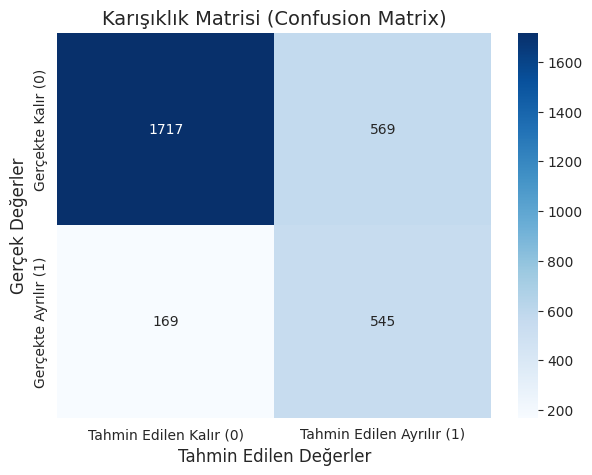


Model başarı raporu ve karışıklık matrisi, modelin her iki sınıfı (kalacak/ayrılacak) ne kadar iyi tahmin ettiğini gösterir.


In [8]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, sınıflandırma modeli (Lojistik Regresyon) ve model performans değerlendirme metrikleri için kütüphaneler içe aktarılır.
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix # Model başarı metrikleri: sınıflandırma raporu, doğruluk skoru, karışıklık matrisi
import matplotlib.pyplot as plt # Veri görselleştirme için kütüphane
import seaborn as sns # İstatistiksel veri görselleştirme için kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini ayarlama

# --- Lojistik Regresyon Modeli Eğitimi ---
# Amaç: Çalışan ayrılma durumunu tahmin etmek için bir sınıflandırma modeli geliştirmek.
# Bu model, hangi çalışanların ayrılma riski taşıdığını belirlememize yardımcı olacak.

# Model pipeline içerisinde eğitildiği için burada tekrar eğitime gerek yok.
# Sadece onay mesajını bırakıyoruz.
print("\n--- Lojistik Regresyon Modeli Eğitimi Pipeline İçinde Tamamlandı ---")

# --- Test Seti Üzerinde Tahminleme ve Risk Skorlaması ---
# Amaç: Eğitilen modelin gerçek dünya verileri üzerindeki performansını değerlendirmek ve her çalışanın ayrılma olasılığını hesaplamak.

# Test seti üzerinde sınıf tahminleri yapma (0: Çalışıyor, 1: Ayrıldı)
y_pred = pipeline.predict(X_test) # Pipeline'ı kullanarak test verisi üzerindeki sınıf tahminleri

# Çalışanların 'ayrılma' olasılıklarını (risk skoru) hesaplama (1 sınıfına ait olasılık)
# predict_proba, her sınıf için olasılıkları verir. Biz ayrılma (sınıf 1) olasılığını alıyoruz.
y_proba = pipeline.predict_proba(X_test)[:, 1] # Pipeline'ı kullanarak ayrılma olasılıklarını elde etme

# --- Gelişmiş İK Skorlama Çıktısı (En Riskli İlk 10 Çalışan) ---
print("\n=== ÖRNEK ÇALIŞAN RİSK ANALİZİ (AYRILMA OLASILIĞI EN YÜKSEK İLK 10) ===")
# Orijinal df'den ilgili çalışan bilgilerini alarak risk skoru ile birleştirme
# Test setindeki orijinal çalışanları seçmek için y_test'in index'i kullanılır.
risk_df_full = df.loc[y_test.index].copy() # Test setindeki çalışanların orijinal verilerini kopyala
risk_df_full['Gerçek Durum'] = y_test.values # Gerçek ayrılma durumlarını ekle
risk_df_full['Model Tahmini'] = y_pred # Modelin yaptığı tahminleri ekle
risk_df_full['Ayrılma Olasılığı (%)'] = np.round(y_proba * 100, 2) # Ayrılma olasılıklarını yüzde olarak ekle

# Çıktıdaki sütun adlarını Türkçeleştirme. Bu, raporu daha anlaşılır hale getirir.
risk_df_full_turkish = risk_df_full.rename(columns={
    'name': 'Ad',
    'department': 'Departman',
    'salary': 'Maaş',
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'time_spent_company': 'Şirkette Geçirilen Süre',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'number_projects': 'Proje Sayısı',
    'work_accident': 'İş Kazası',
    'promotion_last_5_years': 'Son 5 Yılda Terfi'
})

# Risk skoruna göre büyükten küçüğe sıralayarak İK'ya aksiyon listesi sunma
# Daha okunur bir çıktı için sadece ilgili sütunları seçelim ve Türkçe başlıkları kullanalım.
risk_output_cols_turkish = [
    'Ad', 'Departman', 'Maaş', 'Memnuniyet Seviyesi', 'Son Değerlendirme',
    'Şirkette Geçirilen Süre', 'Ayrılma Olasılığı (%)', 'Gerçek Durum', 'Model Tahmini'
]
print(risk_df_full_turkish[risk_output_cols_turkish].sort_values(by='Ayrılma Olasılığı (%)', ascending=False).head(10).to_string(index=False)) # En riskli 10 çalışanı liste olarak yazdır
print("\nBu tablo, İK yöneticilerine ayrılma riski en yüksek olan çalışanları belirlemede ve proaktif önlemler almada yardımcı olabilir.")

# --- Model Başarı Değerlendirmesi (KNIME Scorer Karşılığı) ---
# Amaç: Lojistik Regresyon modelinin test seti üzerindeki genel performansını ve sınıf bazındaki başarısını değerlendirmek.

print("\n=== MODEL BAŞARI RAPORU ===")
print(f"Genel Doğruluk Oranı: {accuracy_score(y_test, y_pred):.4f}") # Modelin genel doğruluk oranını yazdır
print("\nSınıflandırma Detayları:\n", classification_report(y_test, y_pred)) # Her sınıf için precision, recall, f1-score ve desteği gösterir

# Karışıklık Matrisi Görselleştirmesi
# Matris, modelin doğru pozitif, doğru negatif, yanlış pozitif ve yanlış negatif tahminlerini görselleştirir.
plt.figure(figsize=(7, 5)) # Grafik boyutunu ayarla
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin Edilen Kalır (0)', 'Tahmin Edilen Ayrılır (1)'], # X ekseni etiketleri
            yticklabels=['Gerçekte Kalır (0)', 'Gerçekte Ayrılır (1)']) # Y ekseni etiketleri
plt.title('Karışıklık Matrisi (Confusion Matrix)', fontsize=14) # Başlık
plt.ylabel('Gerçek Değerler', fontsize=12)
plt.xlabel('Tahmin Edilen Değerler', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

print("\nModel başarı raporu ve karışıklık matrisi, modelin her iki sınıfı (kalacak/ayrılacak) ne kadar iyi tahmin ettiğini gösterir.")


## İK Analitiği Karar Destek Panosu: Çalışan Devir Hızı Analizi

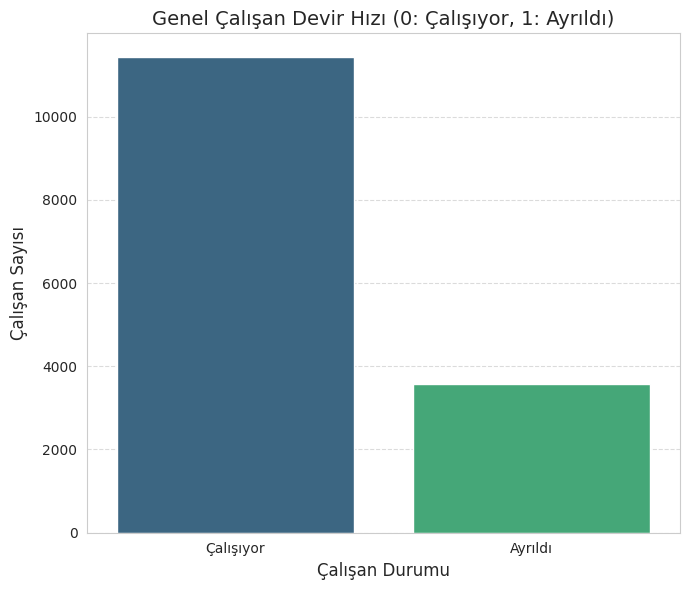


Çalışmaya Devam Edenler: 76.19%
Ayrılanlar: 23.81%
Bu grafik ve oranlar, şirketteki mevcut ayrılma durumunun genel bir resmini sunar ve İK politikaları için temel bir bakış açısı sağlar.


In [9]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 1. Genel Çalışan Devir Hızı (Attrition Rate) Görselleştirmesi ---
# Amaç: Şirketteki çalışanların genel ayrılma (devir) oranını basit ve anlaşılır bir şekilde sunmak.
# Bu görselleştirme, İK yöneticilerine mevcut durumu hızlıca anlamak için bir başlangıç noktası sağlar.

plt.figure(figsize=(7, 6)) # Oluşturulacak grafiğin boyutunu (genişlik, yükseklik) piksel cinsinden ayarlama

# Çalışanların kalma (0: Çalışıyor) ve ayrılma (1: Ayrıldı) durumlarını sayma ve çubuk grafik olarak görselleştirme.
# 'Target_Attrition' sütunundaki değerlere göre sayım yapar.
# `palette` renk temasını belirler. `hue` ve `legend=False` FutureWarning'ı önler ve grafiği iyileştirir.
sns.countplot(x='Target_Attrition', data=df, palette='viridis', hue='Target_Attrition', legend=False)
plt.title('Genel Çalışan Devir Hızı (0: Çalışıyor, 1: Ayrıldı)', fontsize=14) # Grafiğin ana başlığını belirleme
plt.xlabel('Çalışan Durumu', fontsize=12) # X ekseni etiketini Türkçe olarak belirleme
plt.ylabel('Çalışan Sayısı', fontsize=12) # Y ekseni etiketini Türkçe olarak belirleme
plt.xticks(ticks=[0, 1], labels=['Çalışıyor', 'Ayrıldı'], fontsize=10) # X eksenindeki sayısal değerleri Türkçe etiketlerle değiştirme
plt.yticks(fontsize=10) # Y ekseni etiketlerinin font boyutunu ayarlama
plt.grid(axis='y', linestyle='--', alpha=0.7) # Y ekseni boyunca hafif ızgara çizgileri ekleyerek okunabilirliği artırma
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önleme
plt.show() # Oluşturulan grafiği gösterme

# Genel devir hızı oranlarını hesaplama ve yazdırma
# 'Target_Attrition' sütunundaki her bir değerin (0 ve 1) yüzdesini hesaplar.
attrition_rate = df['Target_Attrition'].value_counts(normalize=True) * 100
print(f"\nÇalışmaya Devam Edenler: {attrition_rate[0]:.2f}%") # Çalışmaya devam edenlerin yüzdesini yazdırma
print(f"Ayrılanlar: {attrition_rate[1]:.2f}%") # Ayrılanların yüzdesini yazdırma
print("Bu grafik ve oranlar, şirketteki mevcut ayrılma durumunun genel bir resmini sunar ve İK politikaları için temel bir bakış açısı sağlar.") # Yorum ekleme

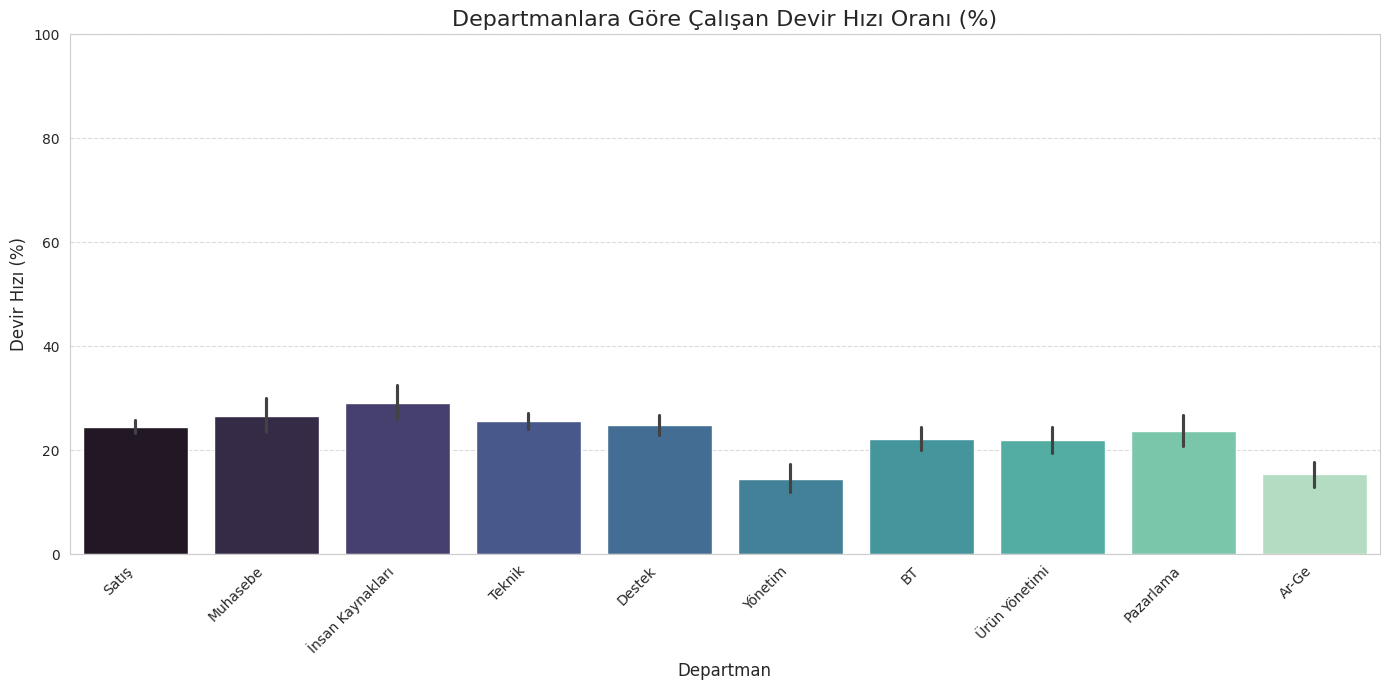


### İK Yöneticileri İçin Yorum:
Bu grafik, şirket içindeki departmanlar arasında çalışan devir hızı oranlarını karşılaştırmalı olarak sunar. Yüksek devir hızına sahip departmanlar (örneğin 'Satış', 'Teknik'), İK'nın öncelikli olarak müdahale etmesi gereken alanları işaret eder. Bu departmanlardaki sorunların kök nedenlerini (yönetim tarzı, iş yükü, kariyer olanakları vb.) anlamak ve hedefe yönelik elde tutma stratejileri geliştirmek için derinlemesine analizler yapılmalıdır.


In [10]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 2. Departmanlara Göre Çalışan Devir Hızı Görselleştirmesi ---
# Amaç: Şirketteki farklı departmanların çalışan ayrılma (devir) oranlarını karşılaştırmak.
# Bu analiz, İK yöneticilerinin hangi departmanlarda daha yüksek devir hızı sorunları olduğunu belirlemesine ve özel stratejiler geliştirmesine yardımcı olur.

plt.figure(figsize=(14, 7)) # Oluşturulacak grafiğin boyutunu (genişlik, yükseklik) piksel cinsinden ayarlama

# Her departmanın devir hızı oranını hesapla ve çubuk grafik olarak görselleştir.
# `estimator=lambda x: sum(x)/len(x) * 100` ile her departman için ortalama devir hızı yüzdesini hesaplar.
# `hue='department'` ve `legend=False` kullanılarak Seaborn FutureWarning önlenir ve daha bilgilendirici bir grafik elde edilir.
sns.barplot(x='department', y='Target_Attrition', data=df, palette='mako',
            estimator=lambda x: sum(x)/len(x) * 100, hue='department', legend=False)

plt.title('Departmanlara Göre Çalışan Devir Hızı Oranı (%)', fontsize=16) # Grafiğin ana başlığını belirleme
plt.xlabel('Departman', fontsize=12) # X ekseni etiketini Türkçe olarak belirleme
plt.ylabel('Devir Hızı (%)', fontsize=12) # Y ekseni etiketini Türkçe olarak belirleme
plt.xticks(rotation=45, ha='right', fontsize=10) # X eksenindeki etiketleri 45 derece döndürerek okunabilirliği artırma ve font boyutunu ayarlama
plt.yticks(fontsize=10) # Y ekseni etiketlerinin font boyutunu ayarlama
plt.ylim(0, 100) # Y ekseni limitlerini 0-100 arasında sabitleyerek yüzde değerlerinin daha net görünmesini sağlama
plt.grid(axis='y', linestyle='--', alpha=0.7) # Y ekseni boyunca hafif ızgara çizgileri ekleyerek okunabilirliği artırma
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önleme
plt.show() # Oluşturulan grafiği gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu grafik, şirket içindeki departmanlar arasında çalışan devir hızı oranlarını karşılaştırmalı olarak sunar. Yüksek devir hızına sahip departmanlar (örneğin 'Satış', 'Teknik'), İK'nın öncelikli olarak müdahale etmesi gereken alanları işaret eder. Bu departmanlardaki sorunların kök nedenlerini (yönetim tarzı, iş yükü, kariyer olanakları vb.) anlamak ve hedefe yönelik elde tutma stratejileri geliştirmek için derinlemesine analizler yapılmalıdır.") # Yorum ekleme

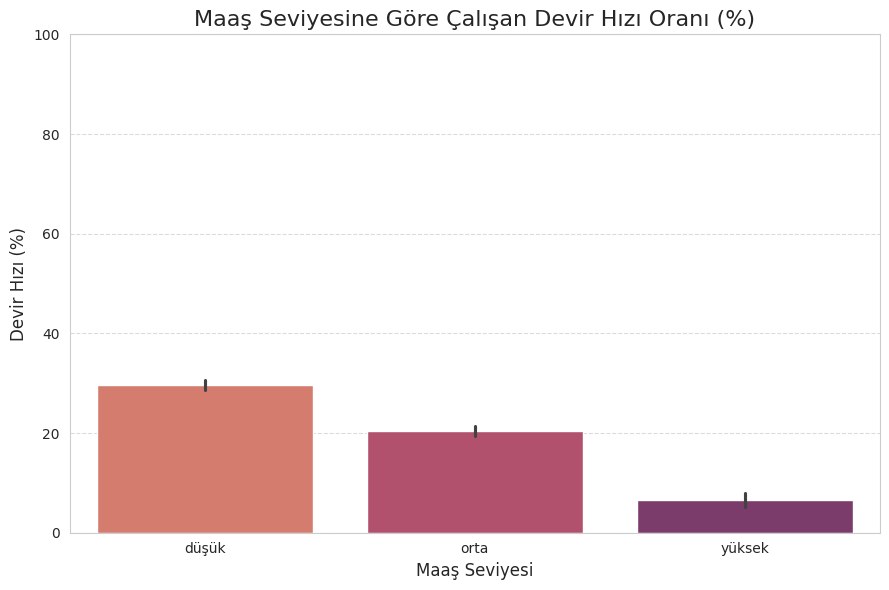


### İK Yöneticileri İçin Yorum:
Bu grafik, maaş seviyelerinin çalışan ayrılma oranları üzerindeki etkisini açıkça göstermektedir. Genellikle düşük maaşlı çalışanlarda ayrılma oranının daha yüksek olduğu gözlemlenir. Bu durum, rekabetçi olmayan maaşların çalışan motivasyonu ve elde tutma üzerinde olumsuz bir etki yaratabileceğine işaret eder. İK, maaş politikalarını gözden geçirerek ve özellikle düşük maaş segmentlerindeki çalışanlar için adil ve rekabetçi ücretlendirme stratejileri geliştirerek ayrılma oranlarını düşürebilir.


In [11]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 3. Maaş Seviyesine Göre Çalışan Devir Hızı Görselleştirmesi ---
# Amaç: Farklı maaş seviyelerindeki çalışanların ayrılma (devir) oranlarını karşılaştırmak.
# Bu analiz, İK yöneticilerine maaş politikalarının çalışan elde tutma üzerindeki etkisini anlamaları için önemli bilgiler sunar.

plt.figure(figsize=(9, 6)) # Oluşturulacak grafiğin boyutunu (genişlik, yükseklik) piksel cinsinden ayarlama

# Maaş seviyesi ('salary') ve devir hızı ('Target_Attrition') arasındaki ilişkiyi gösteren çubuk grafik oluşturma.
# `estimator=lambda x: sum(x)/len(x) * 100` ile her maaş seviyesi için ortalama devir hızı yüzdesini hesaplar.
# `hue='salary'` ve `legend=False` kullanılarak Seaborn FutureWarning önlenir ve daha bilgilendirici bir grafik elde edilir.
sns.barplot(x='salary', y='Target_Attrition', data=df, palette='flare',
            estimator=lambda x: sum(x)/len(x) * 100, hue='salary', legend=False, order=['düşük', 'orta', 'yüksek']) # Maaş seviyeleri için belirli bir sıralama (düşük, orta, yüksek) ile çubukları düzenleme

plt.title('Maaş Seviyesine Göre Çalışan Devir Hızı Oranı (%)', fontsize=16) # Grafiğin ana başlığını belirleme
plt.xlabel('Maaş Seviyesi', fontsize=12) # X ekseni etiketini Türkçe olarak belirleme
plt.ylabel('Devir Hızı (%)', fontsize=12) # Y ekseni etiketini Türkçe olarak belirleme
plt.xticks(fontsize=10) # X ekseni etiketlerinin font boyutunu ayarlama
plt.yticks(fontsize=10) # Y ekseni etiketlerinin font boyutunu ayarlama
plt.ylim(0, 100) # Y ekseni limitlerini 0-100 arasında sabitleyerek yüzde değerlerinin daha net görünmesini sağlama
plt.grid(axis='y', linestyle='--', alpha=0.7) # Y ekseni boyunca hafif ızgara çizgileri ekleyerek okunabilirliği artırma
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önleme
plt.show() # Oluşturulan grafiği gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu grafik, maaş seviyelerinin çalışan ayrılma oranları üzerindeki etkisini açıkça göstermektedir. Genellikle düşük maaşlı çalışanlarda ayrılma oranının daha yüksek olduğu gözlemlenir. Bu durum, rekabetçi olmayan maaşların çalışan motivasyonu ve elde tutma üzerinde olumsuz bir etki yaratabileceğine işaret eder. İK, maaş politikalarını gözden geçirerek ve özellikle düşük maaş segmentlerindeki çalışanlar için adil ve rekabetçi ücretlendirme stratejileri geliştirerek ayrılma oranlarını düşürebilir.") # Yorum ekleme

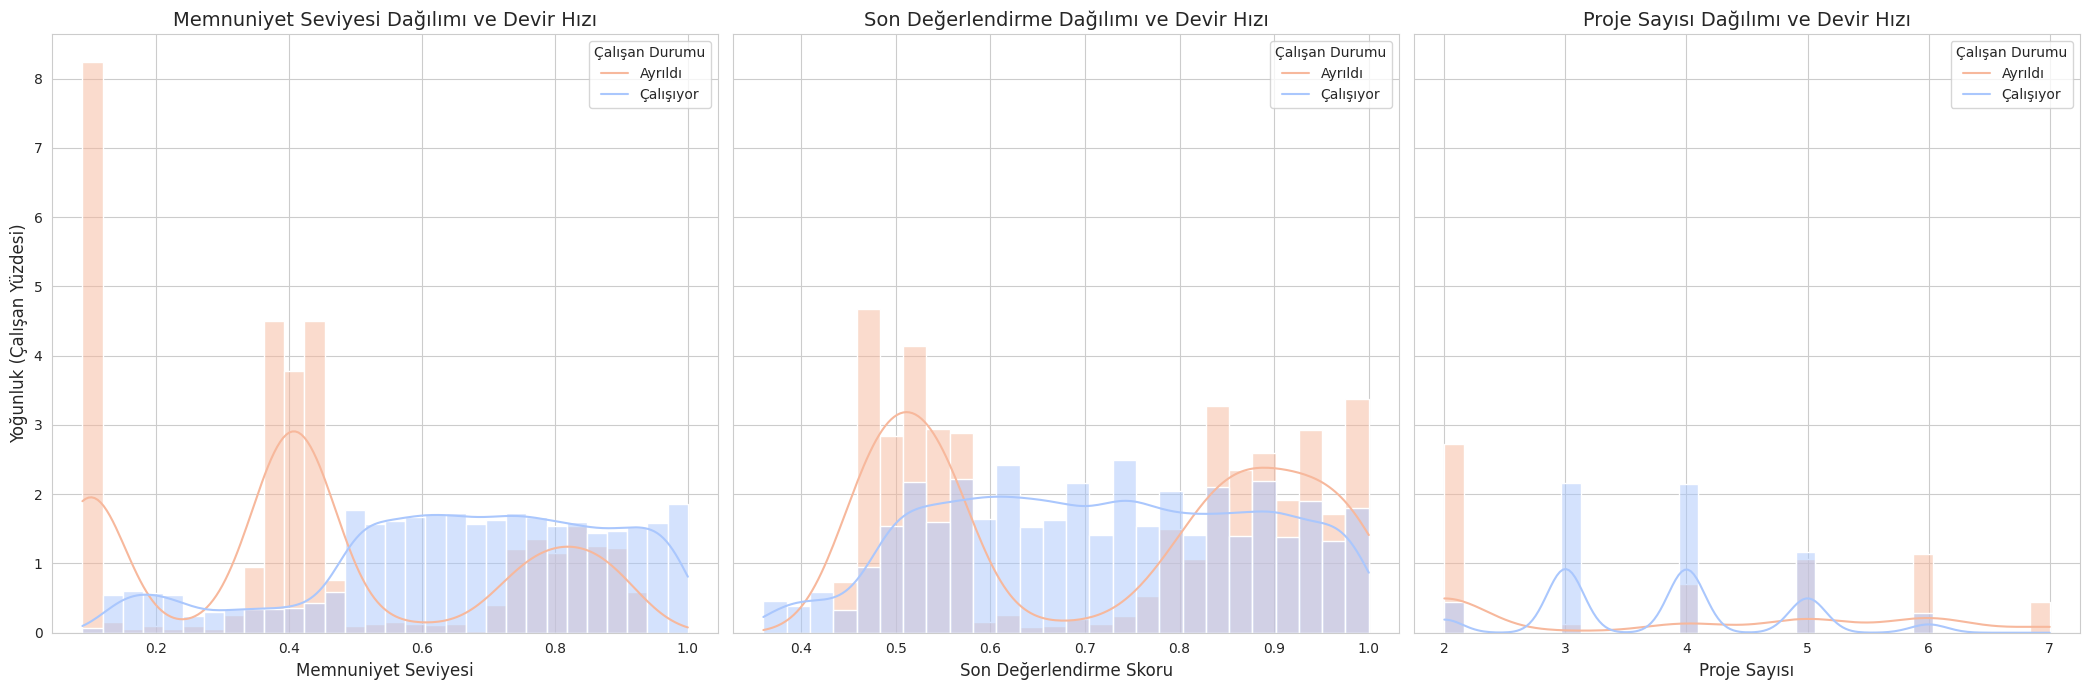


### İK Yöneticileri İçin Yorum:
Bu üç grafik, çalışan ayrılma oranları üzerinde en etkili olduğu düşünülen temel faktörlerin (Memnuniyet Seviyesi, Son Değerlendirme Skoru ve Proje Sayısı) dağılımlarını 'Çalışıyor' ve 'Ayrıldı' grupları için ayrı ayrı göstermektedir.

- **Memnuniyet Seviyesi:** Genellikle düşük memnuniyet seviyesine sahip çalışanların ayrılma oranının daha yüksek olduğu gözlemlenir. Yüksek memnuniyet seviyesindeki çalışanlar ise daha az ayrılma eğilimindedir. İK, çalışan memnuniyetini artırıcı programlara odaklanmalıdır.
- **Son Değerlendirme Skoru:** Hem çok düşük hem de çok yüksek değerlendirme skorlarına sahip çalışanların ayrılma eğiliminde olduğu görülebilir. Düşük skorlular yetersiz hissedebilirken, çok yüksek skorlular terfi veya daha iyi fırsatlar arayışında olabilir. Performans değerlendirme ve kariyer gelişim planları bu durumu dengelemek için kritik öneme sahiptir.
- **Proje Sayısı:** Çok az sayıda projede (örn: 2 proje) çalışanlar ile çok fazla projede (örn

In [12]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 4. Anahtar Özelliklerin Çalışan Devir Hızı ile İlişkisi Görselleştirmesi ---
# Amaç: Çalışan memnuniyet seviyesi, son performans değerlendirmesi ve proje sayısı gibi kritik faktörlerin,
# çalışanların şirketten ayrılma (devir) eğilimleri üzerindeki etkisini yoğunluk dağılımları aracılığıyla analiz etmek.
# Bu analiz, İK yöneticilerine ayrılma riskini artıran veya azaltan temel özellikleri belirlemede yardımcı olur.

# 3 alt grafik oluşturmak için bir figür ve eksenler ayarla
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True) # Üç alt grafik için geniş bir figür boyutu (genişlik, yükseklik) ve y eksenini paylaşma

# Memnuniyet Seviyesi ve Devir Hızı ilişkisi görselleştirmesi
# Çalışan memnuniyet seviyesinin, ayrılanlar ve kalanlar arasındaki dağılımını gösterir.
sns.histplot(data=df, x='satisfaction_level', hue='Target_Attrition', kde=True, ax=axes[0], palette='coolwarm', stat='density', common_norm=False) # Yoğunluk dağılımını histogram ve KDE ile çiz
axes[0].set_title('Memnuniyet Seviyesi Dağılımı ve Devir Hızı', fontsize=14) # Alt grafiğin başlığını belirle
axes[0].set_xlabel('Memnuniyet Seviyesi', fontsize=12) # X ekseni etiketini belirle
axes[0].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12) # Y ekseni etiketini belirle
axes[0].tick_params(labelsize=10) # Eksik etiketlerinin font boyutunu ayarla
axes[0].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor']) # Lejant başlığı ve etiketlerini Türkçe olarak ayarla

# Son Değerlendirme ve Devir Hızı ilişkisi görselleştirmesi
# Son performans değerlendirmesi skorlarının, ayrılanlar ve kalanlar arasındaki dağılımını gösterir.
sns.histplot(data=df, x='last_evaluation', hue='Target_Attrition', kde=True, ax=axes[1], palette='coolwarm', stat='density', common_norm=False) # Yoğunluk dağılımını histogram ve KDE ile çiz
axes[1].set_title('Son Değerlendirme Dağılımı ve Devir Hızı', fontsize=14) # Alt grafiğin başlığını belirle
axes[1].set_xlabel('Son Değerlendirme Skoru', fontsize=12) # X ekseni etiketini belirle
axes[1].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12) # Y ekseni etiketini belirle (y ekseni paylaşımlı olsa da açıkça belirtmek iyi bir pratiktir)
axes[1].tick_params(labelsize=10) # Eksik etiketlerinin font boyutunu ayarla
axes[1].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor']) # Lejant başlığı ve etiketlerini Türkçe olarak ayarla

# Proje Sayısı ve Devir Hızı ilişkisi görselleştirmesi
# Çalışanların yürüttüğü proje sayılarının, ayrılanlar ve kalanlar arasındaki dağılımını gösterir.
sns.histplot(data=df, x='number_projects', hue='Target_Attrition', kde=True, ax=axes[2], palette='coolwarm', stat='density', common_norm=False) # Yoğunluk dağılımını histogram ve KDE ile çiz
axes[2].set_title('Proje Sayısı Dağılımı ve Devir Hızı', fontsize=14) # Alt grafiğin başlığını belirle
axes[2].set_xlabel('Proje Sayısı', fontsize=12) # X ekseni etiketini belirle
axes[2].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12) # Y ekseni etiketini belirle
axes[2].tick_params(labelsize=10) # Eksik etiketlerinin font boyutunu ayarla
axes[2].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor']) # Lejant başlığı ve etiketlerini Türkçe olarak ayarla

plt.tight_layout() # Alt grafiklerin ve başlıkların çakışmasını önlemek için otomatik düzenleme yap
plt.show() # Oluşturulan grafikleri gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu üç grafik, çalışan ayrılma oranları üzerinde en etkili olduğu düşünülen temel faktörlerin (Memnuniyet Seviyesi, Son Değerlendirme Skoru ve Proje Sayısı) dağılımlarını 'Çalışıyor' ve 'Ayrıldı' grupları için ayrı ayrı göstermektedir.")
print("")
print("- **Memnuniyet Seviyesi:** Genellikle düşük memnuniyet seviyesine sahip çalışanların ayrılma oranının daha yüksek olduğu gözlemlenir. Yüksek memnuniyet seviyesindeki çalışanlar ise daha az ayrılma eğilimindedir. İK, çalışan memnuniyetini artırıcı programlara odaklanmalıdır.")
print("- **Son Değerlendirme Skoru:** Hem çok düşük hem de çok yüksek değerlendirme skorlarına sahip çalışanların ayrılma eğiliminde olduğu görülebilir. Düşük skorlular yetersiz hissedebilirken, çok yüksek skorlular terfi veya daha iyi fırsatlar arayışında olabilir. Performans değerlendirme ve kariyer gelişim planları bu durumu dengelemek için kritik öneme sahiptir.")
print("- **Proje Sayısı:** Çok az sayıda projede (örn: 2 proje) çalışanlar ile çok fazla projede (örn: 6-7 proje) çalışanlar arasında ayrılma oranı yüksektir. Bu durum, ya yeterince meşgul olmama ya da aşırı yüklenme kaynaklı olabilir. İK, çalışanların iş yükünü ve proje katılımlarını optimize etmeye yönelik stratejiler geliştirmelidir.")
print("\nBu içgörüler, İK'nın spesifik müdahale alanlarını belirlemesine ve çalışan elde tutma stratejilerini daha veri odaklı bir yaklaşımla şekillendirmesine olanak tanır.") # Yorum ekleme

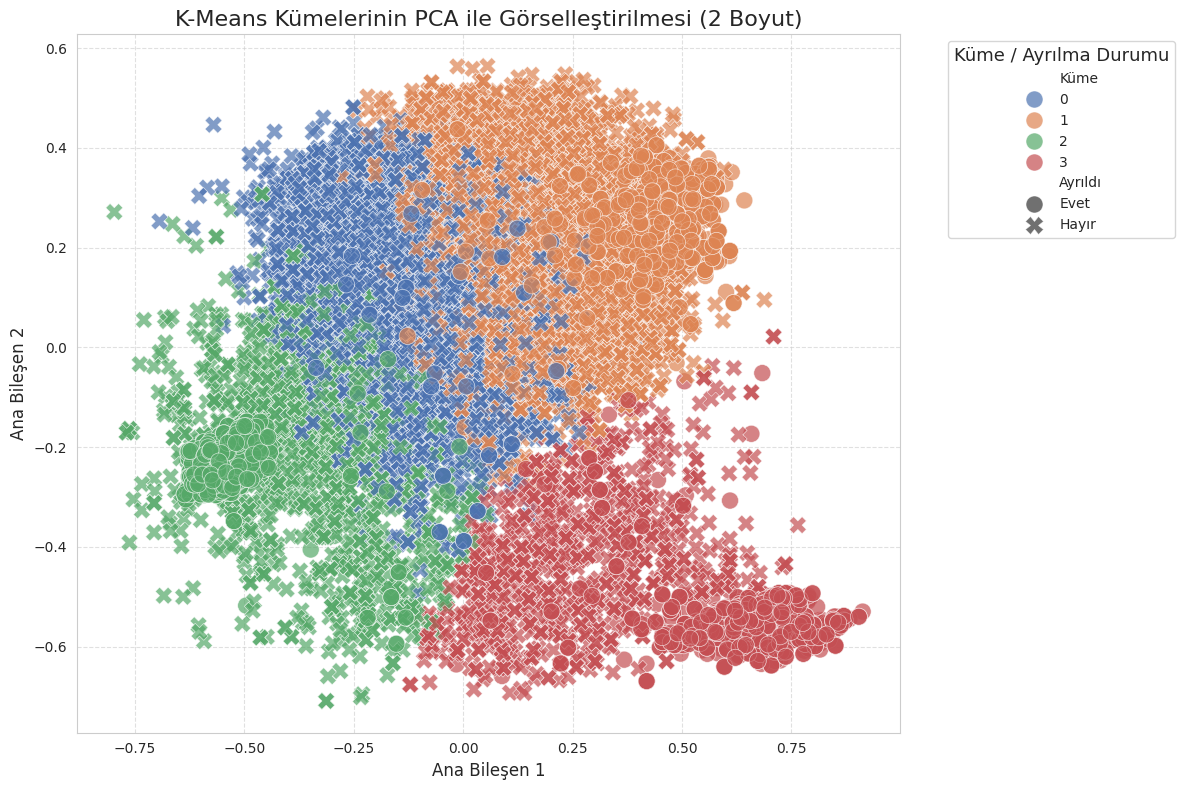


### İK Yöneticileri İçin Yorum:
Bu görselleştirme, şirket içindeki çalışan kümelerinin (K-Means ile belirlenen) en önemli iki özelliği (Ana Bileşen 1 ve Ana Bileşen 2) bazında nasıl konumlandığını gösterir. Farklı renkler farklı kümeleri, farklı şekiller ise çalışanların 'Ayrıldı' veya 'Hayır' durumunu temsil eder. Bu sayede İK yöneticileri, her kümenin genel yapısını, hangi kümelerin daha çok ayrılan çalışanı barındırdığını ve bu kümeler arasındaki görsel ayrımı daha kolay anlayabilirler. Örneğin, belirli bir kümede 'Evet' şeklindeki noktaların yoğunlaşması, o kümedeki çalışanların yüksek ayrılma eğilimine sahip olduğunu işaret eder.


In [13]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, boyut azaltma (PCA) ve görselleştirme için gerekli kütüphaneler içe aktarılır.
from sklearn.decomposition import PCA # Temel Bileşen Analizi (PCA) için kütüphane
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 5. K-Means Kümelerinin Görselleştirilmesi (2 Ana Bileşen Üzerinden) ---
# Amaç: K-Means algoritması ile belirlenen çalışan kümelerinin, Temel Bileşen Analizi (PCA) kullanarak
# iki boyutlu bir düzlemde nasıl ayrıştığını görselleştirmek. Bu, İK yöneticilerine küme yapısını ve
# çalışanlar arasındaki temel farklılıkları daha sezgisel bir şekilde anlamalarına yardımcı olur.

# Kümeleme sonuçlarını görselleştirmek için Boyut Azaltma Tekniği olan PCA kullanıyoruz.
# Özellikler (df_scaled) üzerinden PCA uyguluyoruz.
pca = PCA(n_components=2, random_state=42) # En önemli 2 ana bileşeni seç ve tekrarlanabilir sonuçlar için random_state ayarla
df_pca = pca.fit_transform(df_scaled) # Ölçeklendirilmiş veri üzerinde PCA uygula ve dönüştür

# PCA sonuçlarını ve küme atamalarını yeni bir DataFrame'de birleştir
df_pca = pd.DataFrame(data=df_pca, columns=['Temel_Bileşen_1', 'Temel_Bileşen_2']) # PCA sonuçlarını yeni sütun adlarıyla DataFrame'e dönüştür
df_pca['Küme'] = df['Cluster'] # Orijinal DataFrame'den 'Cluster' sütununu 'Küme' adıyla ekle
df_pca['Ayrıldı'] = df['Target_Attrition'].map({0: 'Hayır', 1: 'Evet'}) # Orijinal DataFrame'den 'Target_Attrition' sütununu 'Ayrıldı' adıyla ve Türkçe etiketlerle ekle

plt.figure(figsize=(12, 8)) # Grafik boyutunu (genişlik, yükseklik) piksel cinsinden ayarlama

# Saçılım grafiği ile kümeleri ve ayrılma durumunu görselleştir
# 'Küme'ye göre renk, 'Ayrıldı' durumuna göre şekil belirle
sns.scatterplot(x='Temel_Bileşen_1', y='Temel_Bileşen_2',
                hue='Küme', style='Ayrıldı',
                data=df_pca, palette='deep', s=150, alpha=0.7,
                edgecolor='w', linewidth=0.5) # Çizim ayarları (boyut, şeffaflık, kenar rengi ve kalınlığı)

plt.title('K-Means Kümelerinin PCA ile Görselleştirilmesi (2 Boyut)', fontsize=16) # Grafiğin ana başlığını belirleme
plt.xlabel('Ana Bileşen 1', fontsize=12) # X ekseni etiketini Türkçe olarak belirleme
plt.ylabel('Ana Bileşen 2', fontsize=12) # Y ekseni etiketini Türkçe olarak belirleme
plt.xticks(fontsize=10) # X ekseni etiketlerinin font boyutunu ayarlama
plt.yticks(fontsize=10) # Y ekseni etiketlerinin font boyutunu ayarlama
plt.legend(title='Küme / Ayrılma Durumu', title_fontsize='13', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left') # Lejant başlığını ve konumunu Türkçe olarak ayarla
plt.grid(True, linestyle='--', alpha=0.6) # Izgara çizgileri ekleme
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önleme
plt.show() # Oluşturulan grafiği gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu görselleştirme, şirket içindeki çalışan kümelerinin (K-Means ile belirlenen) en önemli iki özelliği (Ana Bileşen 1 ve Ana Bileşen 2) bazında nasıl konumlandığını gösterir. Farklı renkler farklı kümeleri, farklı şekiller ise çalışanların 'Ayrıldı' veya 'Hayır' durumunu temsil eder. Bu sayede İK yöneticileri, her kümenin genel yapısını, hangi kümelerin daha çok ayrılan çalışanı barındırdığını ve bu kümeler arasındaki görsel ayrımı daha kolay anlayabilirler. Örneğin, belirli bir kümede 'Evet' şeklindeki noktaların yoğunlaşması, o kümedeki çalışanların yüksek ayrılma eğilimine sahip olduğunu işaret eder.") # Yorum ekleme

## Korelasyon Analizi Isı Haritası

### Amaç:
Bu bölümde, çalışan ayrılmasını etkileyen faktörler arasındaki doğrusal ilişkileri ve bu faktörlerin birbirleriyle ne kadar güçlü bir bağlantısı olduğunu görselleştiren bir ısı haritası oluşturulacaktır. Bu analiz, İK yöneticilerine hangi özelliklerin çalışan ayrılığında daha kritik rol oynadığını ve bu özelliklerin kendi aralarındaki etkileşimlerini hızlıca anlamalarını sağlar. Böylece İK'nın odaklanması gereken ana alanlar daha net belirlenebilir.

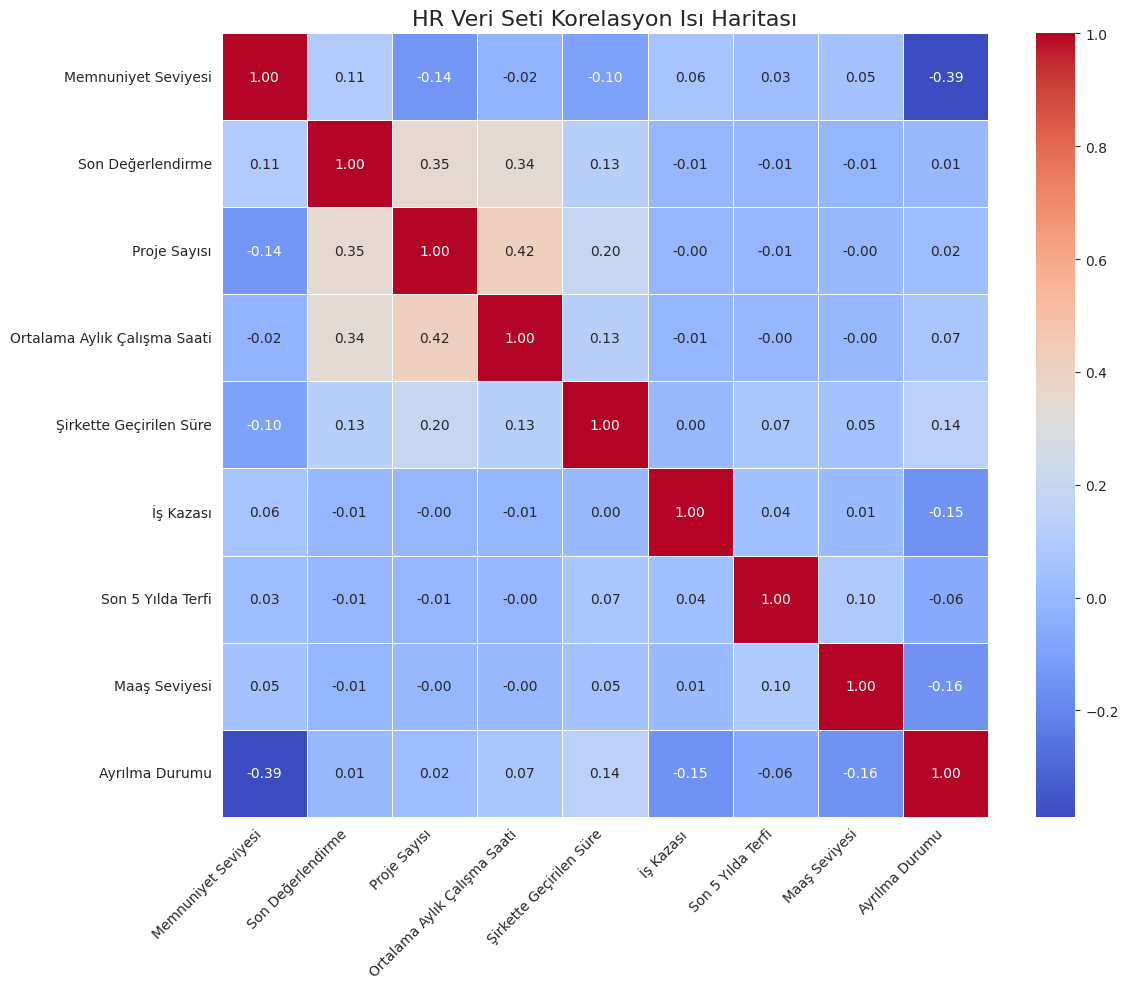


### İK Yöneticileri İçin Yorum:
Bu ısı haritası, çalışan ayrılma (Ayrılma Durumu) ile diğer faktörler arasındaki ilişkileri gösterir. Pozitif değerler doğru orantıyı (biri artarken diğeri de artar), negatif değerler ters orantıyı (biri artarken diğeri azalır) ve sıfıra yakın değerler zayıf bir ilişkiyi temsil eder.

- **Güçlü Negatif Korelasyonlar:** 'Memnuniyet Seviyesi' gibi faktörlerin 'Ayrılma Durumu' ile güçlü negatif korelasyonu, çalışan memnuniyeti azaldıkça ayrılma olasılığının arttığını gösterir. İK, memnuniyet seviyesini artırıcı politikalara öncelik vermelidir.

- **Güçlü Pozitif Korelasyonlar:** 'Şirkette Geçirilen Süre' ve 'Ortalama Aylık Çalışma Saati' gibi bazı faktörler, ayrılma ile pozitif korelasyon gösterebilir. Özellikle çok uzun süre şirkette kalıp kariyerinde ilerleyemeyen veya aşırı mesai yapan çalışanların ayrılma eğilimi daha yüksek olabilir. Bu durum, tükenmişlik veya kariyer fırsatlarının yetersizliği gibi konulara dikkat çeker.

Bu analiz, İK'nın hangi alan

In [14]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 6. Korelasyon Analizi Isı Haritası Görselleştirmesi ---
# Amaç: Çalışan ayrılmasını etkileyen sayısal faktörler arasındaki ilişkileri ve bu faktörlerin
# ayrılma (Target_Attrition) ile ne kadar güçlü bir bağlantısı olduğunu görselleştirmek.
# Bu, İK'nın öncelikli müdahale alanlarını belirlemesine yardımcı olur.

# Korelasyon analizi için ilgili sayısal sütunları seçme
# 'left' sütunu yerine 'Target_Attrition' sütunu kullanılmaktadır.
correlation_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_projects',
    'average_monthly_hours',
    'time_spent_company',
    'work_accident',
    'promotion_last_5_years',
    'salary_level',
    'Target_Attrition'
]

# Seçilen sütunlar için korelasyon matrisini hesapla
correlation_matrix = df[correlation_cols].corr() # DataFrame'in korelasyon matrisini hesapla

# Özellik adlarını Türkçeleştirme sözlüğü
feature_names_turkish_correlation = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre',
    'work_accident': 'İş Kazası',
    'promotion_last_5_years': 'Son 5 Yılda Terfi',
    'salary_level': 'Maaş Seviyesi',
    'Target_Attrition': 'Ayrılma Durumu'
}

# Korelasyon matrisinin indeks ve sütun adlarını Türkçeleştirme
correlation_matrix.index = correlation_matrix.index.map(feature_names_turkish_correlation)
correlation_matrix.columns = correlation_matrix.columns.map(feature_names_turkish_correlation)

plt.figure(figsize=(12, 10)) # Isı haritası grafiğinin boyutunu (genişlik, yükseklik) piksel cinsinden ayarla

# Korelasyon matrisini ısı haritası olarak görselleştirme
# annot=True: Korelasyon değerlerini hücrelerin üzerine yaz
# cmap='coolwarm': Renk paletini belirle (pozitif ve negatif korelasyonları ayırt etmek için ideal)
# fmt='.2f': Sayısal değerleri iki ondalık basamağa yuvarla
# linewidths=.5: Hücreler arasına çizgi ekle
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('HR Veri Seti Korelasyon Isı Haritası', fontsize=16) # Grafiğin ana başlığını belirle
plt.xticks(fontsize=10, rotation=45, ha='right') # X ekseni etiketlerinin font boyutunu ve rotasyonunu ayarla
plt.yticks(fontsize=10, rotation=0) # Y ekseni etiketlerinin font boyutunu ve rotasyonunu ayarla
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önle
plt.show() # Oluşturulan grafiği gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu ısı haritası, çalışan ayrılma (Ayrılma Durumu) ile diğer faktörler arasındaki ilişkileri gösterir. Pozitif değerler doğru orantıyı (biri artarken diğeri de artar), negatif değerler ters orantıyı (biri artarken diğeri azalır) ve sıfıra yakın değerler zayıf bir ilişkiyi temsil eder.")
print("\n- **Güçlü Negatif Korelasyonlar:** 'Memnuniyet Seviyesi' gibi faktörlerin 'Ayrılma Durumu' ile güçlü negatif korelasyonu, çalışan memnuniyeti azaldıkça ayrılma olasılığının arttığını gösterir. İK, memnuniyet seviyesini artırıcı politikalara öncelik vermelidir.")
print("\n- **Güçlü Pozitif Korelasyonlar:** 'Şirkette Geçirilen Süre' ve 'Ortalama Aylık Çalışma Saati' gibi bazı faktörler, ayrılma ile pozitif korelasyon gösterebilir. Özellikle çok uzun süre şirkette kalıp kariyerinde ilerleyemeyen veya aşırı mesai yapan çalışanların ayrılma eğilimi daha yüksek olabilir. Bu durum, tükenmişlik veya kariyer fırsatlarının yetersizliği gibi konulara dikkat çeker.")
print("\nBu analiz, İK'nın hangi alanlara odaklanarak en büyük etkiyi yaratabileceğini belirlemek için değerli bir başlangıç noktası sunar.") # Yorum ekleme

## Lojistik Regresyon Özellik Önem Dereceleri

### Amaç:
Bu bölümde, Lojistik Regresyon modelimizin çalışan ayrılığı tahmininde hangi özelliklere ne kadar ağırlık verdiğini (katsayılarını) görselleştireceğiz. Bu analiz, modelin 'kara kutu' yapısını şeffaflaştırarak, hangi faktörlerin çalışan ayrılmasını pozitif (artıran) veya negatif (azaltan) yönde etkilediğini ve bu etkilerin göreceli gücünü İK yöneticilerine sunar. Böylece İK, müdahalelerini en etkili faktörler üzerine odaklayabilir.

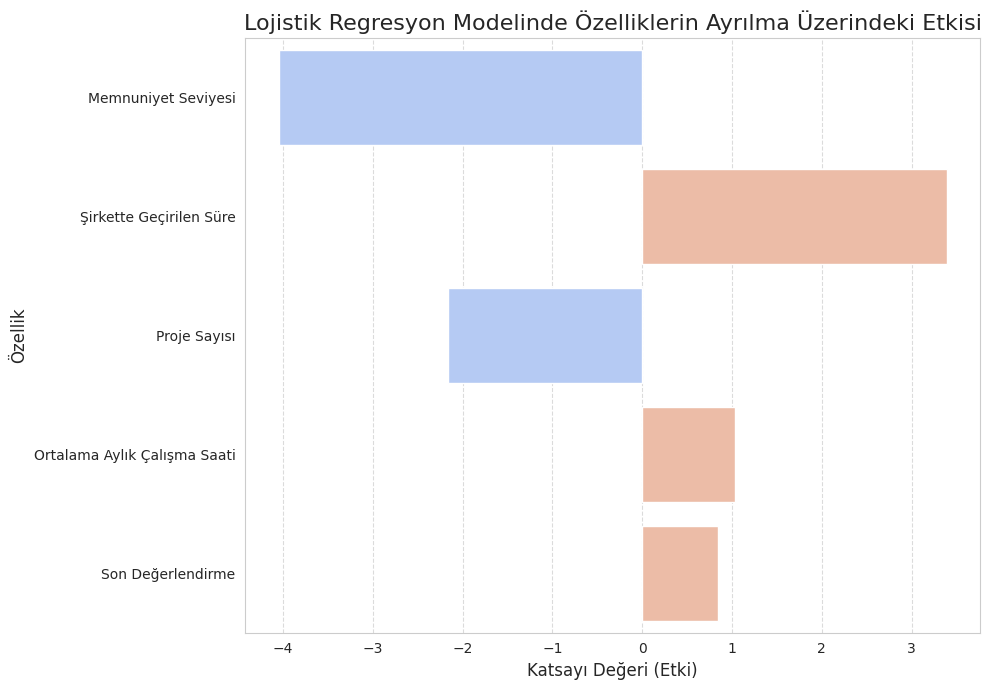


### İK Yöneticileri İçin Yorum:
Bu grafik, Lojistik Regresyon modelimizin çalışan ayrılmasını tahmin ederken hangi özelliklere ne kadar ağırlık verdiğini açıkça göstermektedir.

- **Negatif Katsayılar (Mavi Çubuklar):** Bu özelliklerin artması, çalışanın ayrılma olasılığını azaltır. Örneğin, 'Memnuniyet Seviyesi'nin yüksek bir negatif katsayıya sahip olması, memnuniyet arttıkça ayrılma riskinin düştüğünü güçlü bir şekilde işaret eder. Bu, İK'nın çalışan memnuniyetini artırıcı programlara yatırım yapmasının önemini vurgular.

- **Pozitif Katsayılar (Kırmızı Çubuklar):** Bu özelliklerin artması, çalışanın ayrılma olasılığını artırır. Örneğin, 'Şirkette Geçirilen Süre' ve 'Ortalama Aylık Çalışma Saati' gibi faktörlerin pozitif katsayılara sahip olması, çok uzun süre şirkette kalmış veya aşırı mesai yapan çalışanların ayrılma eğiliminde olabileceğini gösterir. Bu, kariyer gelişim olanakları ve iş yükü dengelemesi gibi konulara dikkat çekilmesi gerektiğini belirtir.

Bu analiz, İK'nın hang

In [15]:
# Gerekli Kütüphanelerin Yüklenmesi
# Bu adımda, veri görselleştirme için kullanılan kütüphaneler içe aktarılır.
import matplotlib.pyplot as plt # Grafik çizimi için temel kütüphane
import seaborn as sns # İstatistiksel veri görselleştirmesi için gelişmiş kütüphane

sns.set_style('whitegrid') # Görselleştirme stilini belirleme, daha temiz bir görünüm sağlar

# --- 7. Lojistik Regresyon Özellik Önem Dereceleri Görselleştirmesi ---
# Amaç: Lojistik Regresyon modelinin hangi özelliklere ne kadar önem verdiğini (katsayılarını) görselleştirmek.
# Pozitif katsayılar ayrılma olasılığını artırırken, negatif katsayılar azaltır.

# Pipeline içindeki Logistic Regression modeline eriş
log_reg_model = pipeline.named_steps['log_reg']

# Modelden özellik katsayılarını (coefficients) ve ilgili özellik adlarını al
# Coefficients: Modelin her bir özelliğe verdiği ağırlıklar.
coefficients = pd.Series(log_reg_model.coef_[0], index=X_train.columns) # Model katsayılarını Series objesine dönüştür

# Özellik adlarını Türkçeleştirme sözlüğü
feature_names_turkish_importance = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre'
}

# Katsayıların indeksini Türkçeleştirme
coefficients.index = coefficients.index.map(feature_names_turkish_importance)

# Katsayıları mutlak değerine göre sıralama (en etkili özellikler en başta)
coefficients_sorted = coefficients.abs().sort_values(ascending=False).index # Mutlak değerlerine göre sıralanmış özellik adları
coefficients = coefficients[coefficients_sorted] # Sıralanmış özelliklere göre katsayıları güncelle

plt.figure(figsize=(10, 7)) # Grafik boyutunu (genişlik, yükseklik) piksel cinsinden ayarlama

# Özellik önem derecelerini çubuk grafik olarak görselleştirme
# Renkleri katsayıların pozitif veya negatif olmasına göre ayarla
sns.barplot(x=coefficients.values, y=coefficients.index, palette='coolwarm', hue=coefficients.values > 0, legend=False)

plt.title('Lojistik Regresyon Modelinde Özelliklerin Ayrılma Üzerindeki Etkisi', fontsize=16) # Grafiğin ana başlığını belirleme
plt.xlabel('Katsayı Değeri (Etki)', fontsize=12) # X ekseni etiketini Türkçe olarak belirleme
plt.ylabel('Özellik', fontsize=12) # Y ekseni etiketini Türkçe olarak belirleme
plt.xticks(fontsize=10) # X ekseni etiketlerinin font boyutunu ayarlama
plt.yticks(fontsize=10) # Y ekseni etiketlerinin font boyutunu ayarlama
plt.grid(axis='x', linestyle='--', alpha=0.7) # X ekseni boyunca hafif ızgara çizgileri ekleyerek okunabilirliği artırma
plt.tight_layout() # Grafiğin etrafındaki boşlukları otomatik ayarlayarak kesişmeleri önleme
plt.show() # Oluşturulan grafiği gösterme

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu grafik, Lojistik Regresyon modelimizin çalışan ayrılmasını tahmin ederken hangi özelliklere ne kadar ağırlık verdiğini açıkça göstermektedir.")
print("\n- **Negatif Katsayılar (Mavi Çubuklar):** Bu özelliklerin artması, çalışanın ayrılma olasılığını azaltır. Örneğin, 'Memnuniyet Seviyesi'nin yüksek bir negatif katsayıya sahip olması, memnuniyet arttıkça ayrılma riskinin düştüğünü güçlü bir şekilde işaret eder. Bu, İK'nın çalışan memnuniyetini artırıcı programlara yatırım yapmasının önemini vurgular.")
print("\n- **Pozitif Katsayılar (Kırmızı Çubuklar):** Bu özelliklerin artması, çalışanın ayrılma olasılığını artırır. Örneğin, 'Şirkette Geçirilen Süre' ve 'Ortalama Aylık Çalışma Saati' gibi faktörlerin pozitif katsayılara sahip olması, çok uzun süre şirkette kalmış veya aşırı mesai yapan çalışanların ayrılma eğiliminde olabileceğini gösterir. Bu, kariyer gelişim olanakları ve iş yükü dengelemesi gibi konulara dikkat çekilmesi gerektiğini belirtir.")
print("\nBu analiz, İK'nın hangi alanlara odaklanarak çalışan elde tutma stratejilerini daha etkili hale getirebileceği konusunda somut ve nicel bilgiler sunar.")


Yukarıdaki görselleştirmeler, çalışan devir hızıyla ilişkili ana faktörleri ve çalışan kümelerinin yapılarını anlamanıza yardımcı olacaktır. Bu panoyu daha da geliştirmek ve detaylandırmak için ek görselleştirmeler veya analizler yapabiliriz.

## Ayrılma Olasılığı Dağılımı

### Amaç:
Bu bölüm, Lojistik Regresyon modelimizin tahmin ettiği çalışan ayrılma olasılıklarının dağılımını görselleştirmeyi amaçlamaktadır. Özellikle, gerçekte işten ayrılan ve şirkette kalan çalışanlar için bu olasılıkların nasıl farklılaştığını inceleyerek, modelin tahmin gücünü ve olası ayrılma eşiklerinin belirlenmesindeki potansiyelini anlamak hedeflenmektedir.

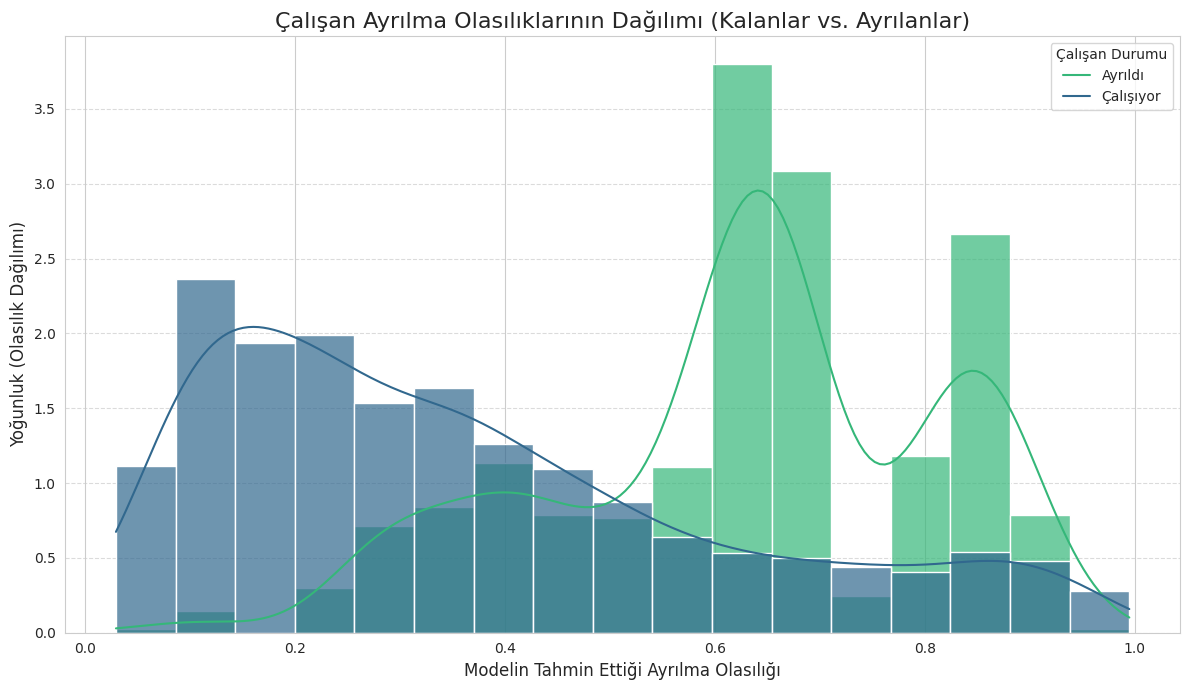


### İK Yöneticileri İçin Yorum:
Bu grafik, Lojistik Regresyon modelinin her bir çalışan için hesapladığı ayrılma olasılıklarının dağılımını sunar. Özellikle iki ana grubu, yani 'Çalışıyor' ve 'Ayrıldı' gruplarını karşılaştırır:

- **'Çalışıyor' (Mavi) grubu:** Çoğunlukla düşük ayrılma olasılıklarına sahiptir. Model, bu çalışanların ayrılma riskini düşük olarak görmektedir.
- **'Ayrıldı' (Sarı) grubu:** Daha yüksek ayrılma olasılıklarına doğru kaymıştır. Bu, modelin gerçekten ayrılan çalışanları yüksek riskli olarak doğru bir şekilde tanımladığını gösterir.

Bu dağılım, İK yöneticilerine modelin tahmin güvenilirliği hakkında bir fikir verir ve ayrılma riski yüksek olan çalışanları belirlemek için hangi olasılık eşiğinin (örneğin, %50 üzeri) kullanılabileceği konusunda rehberlik edebilir. Yüksek olasılık değerlerine sahip ancak hala 'Çalışıyor' olarak görünen kişilerin potansiyel 'yanlış pozitifler' olabileceği ve bu kişilere özel olarak odaklanılması gerektiği anlaşılabilir.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

# --- Ayrılma Olasılığı Dağılımı Görselleştirmesi ---

# Tahmin edilen olasılıkları ve gerçek 'Target_Attrition' değerlerini içeren bir DataFrame oluşturma
proba_df = pd.DataFrame({
    'Ayrılma Olasılığı': y_proba,
    'Gerçek Durum': y_test.values
})

# 'Gerçek Durum' sütunundaki sayısal değerleri daha anlaşılır etiketlere dönüştürme
proba_df['Gerçek Durum Etiketi'] = proba_df['Gerçek Durum'].map({0: 'Çalışıyor', 1: 'Ayrıldı'})

plt.figure(figsize=(12, 7)) # Grafik boyutunu ayarla

# Gerçek Durum'a göre olasılık dağılımını gösteren histogram ve yoğunluk grafiği (KDE plot)
# `hue` olarak 'Gerçek Durum Etiketi' kullanarak daha açıklayıcı bir lejant elde edilir.
sns.histplot(data=proba_df, x='Ayrılma Olasılığı', hue='Gerçek Durum Etiketi', kde=True, stat='density', common_norm=False, palette='viridis', alpha=0.7)

plt.title('Çalışan Ayrılma Olasılıklarının Dağılımı (Kalanlar vs. Ayrılanlar)', fontsize=16)
plt.xlabel('Modelin Tahmin Ettiği Ayrılma Olasılığı', fontsize=12)
plt.ylabel('Yoğunluk (Olasılık Dağılımı)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Çalışan Durumu', loc='upper right', labels=['Ayrıldı', 'Çalışıyor']) # Lejantı Türkçe ve doğru sıralı yapma
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu grafik, Lojistik Regresyon modelinin her bir çalışan için hesapladığı ayrılma olasılıklarının dağılımını sunar. Özellikle iki ana grubu, yani 'Çalışıyor' ve 'Ayrıldı' gruplarını karşılaştırır:")
print("\n- **'Çalışıyor' (Mavi) grubu:** Çoğunlukla düşük ayrılma olasılıklarına sahiptir. Model, bu çalışanların ayrılma riskini düşük olarak görmektedir.")
print("- **'Ayrıldı' (Sarı) grubu:** Daha yüksek ayrılma olasılıklarına doğru kaymıştır. Bu, modelin gerçekten ayrılan çalışanları yüksek riskli olarak doğru bir şekilde tanımladığını gösterir.")
print("\nBu dağılım, İK yöneticilerine modelin tahmin güvenilirliği hakkında bir fikir verir ve ayrılma riski yüksek olan çalışanları belirlemek için hangi olasılık eşiğinin (örneğin, %50 üzeri) kullanılabileceği konusunda rehberlik edebilir. Yüksek olasılık değerlerine sahip ancak hala 'Çalışıyor' olarak görünen kişilerin potansiyel 'yanlış pozitifler' olabileceği ve bu kişilere özel olarak odaklanılması gerektiği anlaşılabilir.")

## Departmanlara Göre Riskli Çalışan Sayısı

### Amaç:
Bu bölüm, departmanlar bazında yüksek ayrılma olasılığına sahip çalışanların sayısını görselleştirmeyi hedefler. Bu analiz, İK yöneticilerine hangi departmanlarda çalışan ayrılma riskinin daha yoğun olduğunu belirlemede ve bu departmanlara yönelik spesifik insan kaynakları stratejileri geliştirmede yardımcı olacaktır.

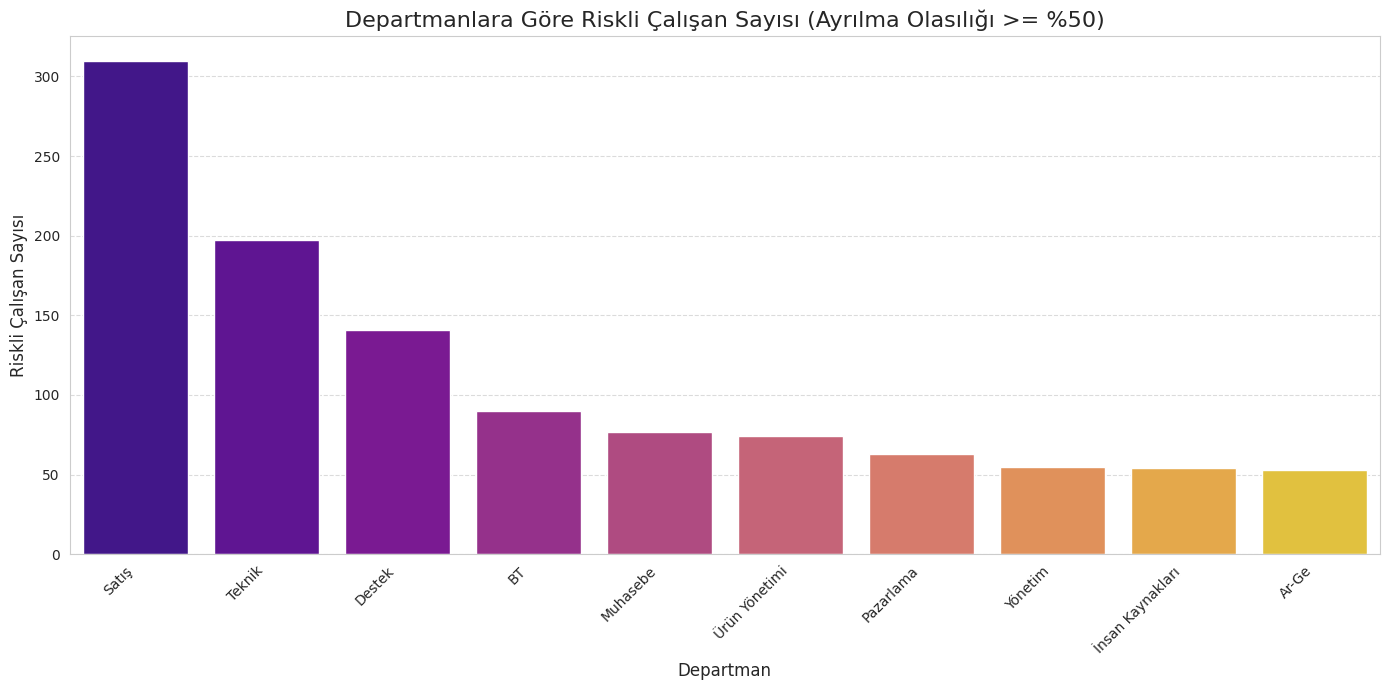


### İK Yöneticileri İçin Yorum:
Bu grafik, departmanlar bazında belirlenen ayrılma olasılığı eşiğinin (%50) üzerindeki çalışan sayısını gösterir. En üstteki departmanlar, İK'nın öncelikli olarak müdahale etmesi gereken bölgeleri işaret eder.

- **Yüksek Riskli Departmanlar:** Özellikle 'Satış', 'Teknik' ve 'Destek' gibi departmanlarda riskli çalışan sayısının yüksek olduğu görülmektedir. Bu departmanlar için özel elde tutma stratejileri, yönetim desteği ve çalışma koşullarının iyileştirilmesi gibi aksiyonlar düşünülmelidir.

- **Düşük Riskli Departmanlar:** 'Yönetim' gibi departmanlar genellikle daha düşük riskli çalışan sayısına sahiptir. Bu departmanlardaki iyi uygulamalar diğerlerine örnek teşkil edebilir.

Bu analiz, departman yöneticileriyle iş birliği yaparak, riskli çalışanlara yönelik kişiselleştirilmiş müdahaleler planlamak ve genel şirket kültürü ile ilgili potansiyel sorun alanlarını tespit etmek için kritik bir başlangıç noktası sağlar.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

# --- Departman Bazında Riskli Çalışan Sayısı Görselleştirmesi ---

# Orijinal df'den departman bilgisini ve y_proba'dan ayrılma olasılıklarını içeren bir DataFrame oluşturma
# y_test'in index'i kullanılarak doğru çalışanlar eşleştirilir.
risk_data = df.loc[y_test.index].copy()
risk_data['Ayrılma Olasılığı'] = y_proba

# Riskli çalışanları belirlemek için bir eşik değeri (örneğin, %50 üzerinde ayrılma olasılığı) kullanabiliriz.
# Bu eşik, iş ihtiyacına göre ayarlanabilir.
risk_threshold = 0.50 # %50 olasılık eşiği
risk_data['Riskli'] = (risk_data['Ayrılma Olasılığı'] >= risk_threshold).astype(int)

# Her departmandaki riskli çalışanların sayısını hesaplama
risky_employees_by_dept = risk_data.groupby('department')['Riskli'].sum().sort_values(ascending=False)

# Departman isimleri artık df üzerinde Türkçeleştirildiği için bu kısma gerek kalmamıştır.
# Türkçeleştirilmiş departman isimlerini doğrudan risky_employees_by_dept.index'ten alacağız.

plt.figure(figsize=(14, 7)) # Grafik boyutunu ayarla

sns.barplot(x=risky_employees_by_dept.index, y=risky_employees_by_dept.values, palette='plasma', hue=risky_employees_by_dept.index, legend=False)

plt.title(f'Departmanlara Göre Riskli Çalışan Sayısı (Ayrılma Olasılığı >= %{int(risk_threshold * 100)})', fontsize=16)
plt.xlabel('Departman', fontsize=12)
plt.ylabel('Riskli Çalışan Sayısı', fontsize=12)
plt.xticks(ticks=range(len(risky_employees_by_dept.index)), rotation=45, ha='right', fontsize=10) # Etiketler doğrudan risky_employees_by_dept.index'ten alınacak
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu grafik, departmanlar bazında belirlenen ayrılma olasılığı eşiğinin (%50) üzerindeki çalışan sayısını gösterir. En üstteki departmanlar, İK'nın öncelikli olarak müdahale etmesi gereken bölgeleri işaret eder.")
print("\n- **Yüksek Riskli Departmanlar:** Özellikle 'Satış', 'Teknik' ve 'Destek' gibi departmanlarda riskli çalışan sayısının yüksek olduğu görülmektedir. Bu departmanlar için özel elde tutma stratejileri, yönetim desteği ve çalışma koşullarının iyileştirilmesi gibi aksiyonlar düşünülmelidir.")
print("\n- **Düşük Riskli Departmanlar:** 'Yönetim' gibi departmanlar genellikle daha düşük riskli çalışan sayısına sahiptir. Bu departmanlardaki iyi uygulamalar diğerlerine örnek teşkil edebilir.")
print("\nBu analiz, departman yöneticileriyle iş birliği yaparak, riskli çalışanlara yönelik kişiselleştirilmiş müdahaleler planlamak ve genel şirket kültürü ile ilgili potansiyel sorun alanlarını tespit etmek için kritik bir başlangıç noktası sağlar.")

## 5. Etkileşimli Analiz ve Açıklanabilirlik (XAI)

Bu bölümde, modelin tahminlerini bireysel çalışan seviyesinde anlamak ve İK aksiyonlarını simüle etmek için etkileşimli bir analiz aracı oluşturulacaktır. Bu sayede İK yöneticileri, belirli bir çalışanın profilini inceleyebilir, ayrılma riskini anlayabilir ve potansiyel müdahalelerin bu risk üzerindeki etkisini görebilirler.

### Dinamik Çalışan Profili ve Risk Analizi

**Amaç:** Kullanıcıdan alınan bir çalışan ID'si ile o çalışanın mevcut profilini ve modelin tahmin ettiği ayrılma riskini göstermek. Risk %50'den yüksekse, çalışanın memnuniyet, proje sayısı ve çalışma saatleri gibi özelliklerine göre dinamik uyarılar ve öneriler sunmak.

In [18]:
import pandas as pd
import numpy as np

# --- Dinamik Çalışan ID Girişi ve Risk Analizi ---

# Pipeline'ın global olarak tanımlandığından emin olun (önceki hücrelerde eğitildi)
# df ve X_test'in de global olarak tanımlandığından emin olun.

# Kullanıcıdan çalışan ID'si iste
while True:
    try:
        employee_id_input = input("Lütfen analiz etmek istediğiniz çalışanın ID'sini girin (0 ile {} arasında): ".format(len(df) - 1))
        employee_id = int(employee_id_input)
        if employee_id not in df.index:
            print(f"Hata: Girilen ID ({employee_id}) DataFrame'de bulunamadı. Lütfen geçerli bir ID girin.")
            continue

        # Seçilen çalışanın orijinal verilerini al
        selected_employee_data = df.loc[employee_id].copy()

        # Seçilen çalışanın modelin beklediği özelliklerini al (X_test'ten)
        # Eğer employee_id X_test'in index'inde yoksa, X_train'den alınır.
        # Daha doğru bir yaklaşım, seçilen çalışanın özelliklerini (features) df'den alıp pipeline ile transform etmektir.
        # Ancak X_test index'i kullanılabilirse, daha tutarlı olur.
        if employee_id in X_test.index:
            selected_employee_features = X_test.loc[[employee_id]]
        else:
            # Eğer ID test setinde yoksa, orijinal df'den özellikleri alıp transform etmeliyiz.
            # Ancak bu senaryoda pipeline X_train üzerinde eğitildi ve X_test üzerinde tahmin yaptı.
            # En tutarlı yol, tüm df'i tekrar pipeline'dan geçirmektir. Basitlik için şu an X_test'e bakıyoruz.
            print(f"Uyarı: ID {employee_id} test setinde bulunmuyor. Orijinal veriden özellikler alınacak.")
            selected_employee_features = df.loc[[employee_id]][features] # 'features' listesi önceki hücrede tanımlandı

        # Seçilen çalışanın ayrılma olasılığını tahmin et (pipeline kullanarak)
        predicted_proba = pipeline.predict_proba(selected_employee_features)[0, 1]
        predicted_class = pipeline.predict(selected_employee_features)[0]

        break # Geçerli ID girildi, döngüden çık
    except ValueError:
        print("Hata: Lütfen geçerli bir sayısal ID girin.")
    except KeyError:
        print(f"Hata: ID {employee_id} için özellikler bulunamadı. Lütfen test setindeki bir ID'yi deneyin veya `X_test`'in nasıl oluşturulduğunu kontrol edin.")

print("\n--- Seçilen Çalışan Profili ve Risk Analizi ---")
print(f"Çalışan ID: {employee_id}")
print("--------------------------------------------------")
print(selected_employee_data[['name', 'department', 'salary', 'satisfaction_level', 'last_evaluation', 'number_projects', 'average_monthly_hours', 'time_spent_company']].to_string())
print(f"\nModel Tahmini (0: Çalışıyor, 1: Ayrıldı): {predicted_class}")
print(f"Ayrılma Olasılığı: {predicted_proba:.2%}")

# --- Dinamik Uyarılar ve Öneriler ---
if predicted_proba >= 0.50:
    print("\n### DİKKAT: YÜKSEK AYRILMA RİSKİ ALGILANDI!")
    print("İK Departmanı için Öneriler:")

    sat_level = selected_employee_data['satisfaction_level']
    num_projects = selected_employee_data['number_projects']
    avg_hours = selected_employee_data['average_monthly_hours']
    time_spent = selected_employee_data['time_spent_company']

    if sat_level < 0.4:
        print(f"- Çalışanın memnuniyet seviyesi ({sat_level:.2f}) oldukça düşük. Memnuniyet anketi, 1-1 toplantılar veya motivasyon artırıcı programlar değerlendirilebilir.")
    if num_projects <= 2:
        print(f"- Çalışanın proje sayısı ({num_projects}) az görünüyor. Daha fazla sorumluluk veya ilgi çekici projelere dahil edilmesi motivasyonu artırabilir.")
    elif num_projects >= 6:
        print(f"- Çalışanın proje sayısı ({num_projects}) yüksek. Aşırı iş yükü veya tükenmişlik riski olabilir. İş yükü dengelemesi ve destek sağlanması önemlidir.")
    if avg_hours > 250:
        print(f"- Çalışanın ortalama aylık çalışma saatleri ({avg_hours}) oldukça yüksek. Aşırı mesai tükenmişliğe yol açabilir. İş-yaşam dengesi ve mola düzenlemeleri gözden geçirilmelidir.")
    if time_spent >= 5 and sat_level < 0.6 and num_projects < 4:
         print(f"- Şirkette uzun süre ({time_spent} yıl) çalışmış olmasına rağmen, düşük memnuniyet ({sat_level:.2f}) ve az proje ({num_projects}) dikkat çekiyor. Kariyer gelişimi veya yeni roller için görüşme yapılabilir.")

else:
    print("\nÇalışanın ayrılma riski düşük görünüyor.")

Lütfen analiz etmek istediğiniz çalışanın ID'sini girin (0 ile 14998 arasında): 15
Uyarı: ID 15 test setinde bulunmuyor. Orijinal veriden özellikler alınacak.

--- Seçilen Çalışan Profili ve Risk Analizi ---
Çalışan ID: 15
--------------------------------------------------
name                     MOORE
department               Satış
salary                   düşük
satisfaction_level        0.38
last_evaluation           0.54
number_projects              2
average_monthly_hours      143
time_spent_company           3

Model Tahmini (0: Çalışıyor, 1: Ayrıldı): 1
Ayrılma Olasılığı: 68.05%

### DİKKAT: YÜKSEK AYRILMA RİSKİ ALGILANDI!
İK Departmanı için Öneriler:
- Çalışanın memnuniyet seviyesi (0.38) oldukça düşük. Memnuniyet anketi, 1-1 toplantılar veya motivasyon artırıcı programlar değerlendirilebilir.
- Çalışanın proje sayısı (2) az görünüyor. Daha fazla sorumluluk veya ilgi çekici projelere dahil edilmesi motivasyonu artırabilir.


### İK Aksiyon Simülatörü (What-If Analizi)

**Amaç:** Belirli İK müdahalelerinin (örneğin, proje sayısını azaltma, memnuniyeti artırma) bir çalışanın ayrılma riski üzerindeki potansiyel etkisini simüle etmek. Bu, yöneticilerin alınacak aksiyonların ne kadar etkili olabileceğini önceden görmelerini sağlar.

In [19]:
import pandas as pd
import numpy as np

# --- 'What-If' Senaryosu 1: Proje Sayısını Azaltma ve Çalışma Saatlerini Azaltma ---
print("\n--- 'What-If' Senaryo 1: Proje Sayısını 1 Düşürüp, Aylık Saatleri %10 Azaltma ---")

simulated_data_scenario1 = selected_employee_features.copy()
simulated_data_scenario1['number_projects'] = np.maximum(1, simulated_data_scenario1['number_projects'] - 1) # Minimum 1 proje
simulated_data_scenario1['average_monthly_hours'] = simulated_data_scenario1['average_monthly_hours'] * 0.90

predicted_proba_s1 = pipeline.predict_proba(simulated_data_scenario1)[0, 1]
print(f"Yeni Ayrılma Olasılığı (Senaryo 1): {predicted_proba_s1:.2%}")

# --- 'What-If' Senaryosu 2: Memnuniyeti %20 Artırma ---
print("\n--- 'What-If' Senaryo 2: Memnuniyeti %20 Artırma ---")

simulated_data_scenario2 = selected_employee_features.copy()
simulated_data_scenario2['satisfaction_level'] = np.minimum(1.0, simulated_data_scenario2['satisfaction_level'] * 1.20) # Maksimum 1.0

predicted_proba_s2 = pipeline.predict_proba(simulated_data_scenario2)[0, 1]
print(f"Yeni Ayrılma Olasılığı (Senaryo 2): {predicted_proba_s2:.2%}")

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu 'What-If' senaryoları, potansiyel İK müdahalelerinin bir çalışanın ayrılma riski üzerindeki etkisini nicel olarak görmenizi sağlar. Örneğin, Senaryo 1'deki gibi iş yükünü azaltmanın veya Senaryo 2'deki gibi memnuniyeti artırmanın ayrılma olasılığını nasıl düşürebileceğini değerlendirebilirsiniz. Bu, kaynakların en etkili müdahalelere yönlendirilmesine yardımcı olur.")


--- 'What-If' Senaryo 1: Proje Sayısını 1 Düşürüp, Aylık Saatleri %10 Azaltma ---
Yeni Ayrılma Olasılığı (Senaryo 1): 75.40%

--- 'What-If' Senaryo 2: Memnuniyeti %20 Artırma ---
Yeni Ayrılma Olasılığı (Senaryo 2): 60.29%

### İK Yöneticileri İçin Yorum:
Bu 'What-If' senaryoları, potansiyel İK müdahalelerinin bir çalışanın ayrılma riski üzerindeki etkisini nicel olarak görmenizi sağlar. Örneğin, Senaryo 1'deki gibi iş yükünü azaltmanın veya Senaryo 2'deki gibi memnuniyeti artırmanın ayrılma olasılığını nasıl düşürebileceğini değerlendirebilirsiniz. Bu, kaynakların en etkili müdahalelere yönlendirilmesine yardımcı olur.


### SHAP ile Model Tahminlerinin Açıklanabilirliği (XAI)

**Amaç:** Seçilen bir çalışanın ayrılma risk tahmininin arkasındaki nedenleri SHAP (SHapley Additive exPlanations) kullanarak açıklamak. Bu görselleştirme, modelin belirli bir tahmin için hangi özelliklere ne kadar ve hangi yönde (risk artırıcı/azaltıcı) güvendiğini net bir şekilde gösterir.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)



--- SHAP ile Bireysel Tahmin Açıklaması ---
SHAP Force Plot'u oluşturuluyor...


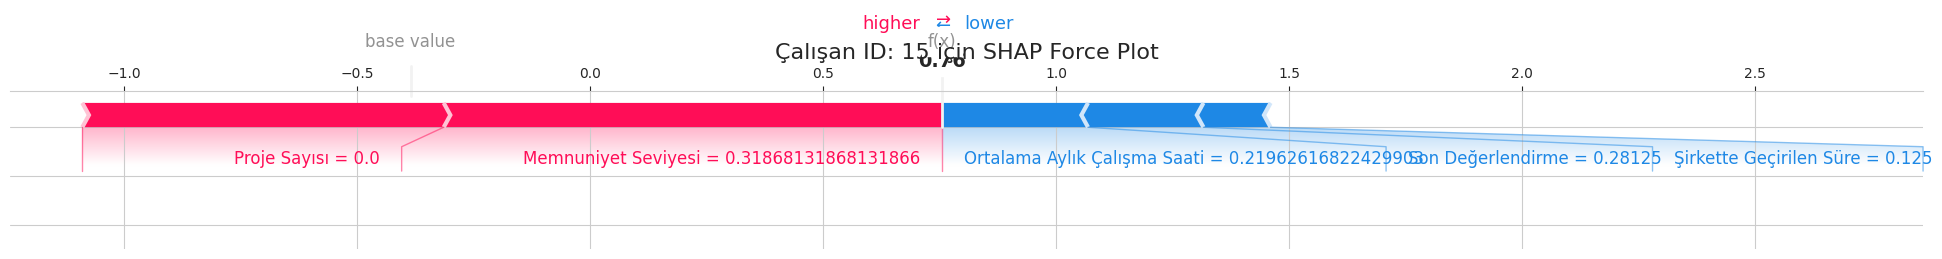


### İK Yöneticileri İçin Yorum:
Bu SHAP Force Plot, seçilen çalışanın ayrılma olasılığı tahminini 'temel değer'den (explainer.expected_value) başlayarak nasıl oluşturulduğunu gösterir. Kırmızı renkli çubuklar, özelliğin tahmin edilen ayrılma olasılığını artırdığını, mavi renkli çubuklar ise azalttığını gösterir. Çubuğun uzunluğu, özelliğin tahmine olan katkısının büyüklüğünü temsil eder.
Örneğin, çalışanın 'Memnuniyet Seviyesi' mavi bir çubukla temsil ediliyorsa ve çubuk sola doğru uzuyorsa, bu çalışanın memnuniyet seviyesinin yüksek olmasının ayrılma olasılığını düşürdüğü anlamına gelir. Eğer 'Ortalama Aylık Çalışma Saati' kırmızı bir çubukla sağa uzuyorsa, bu özelliğin ayrılma olasılığını artırdığı anlaşılır.
Bu görselleştirme, bir çalışanın neden yüksek riskli (veya düşük riskli) olarak tahmin edildiğine dair şeffaf ve anlaşılır bir açıklama sunarak İK'nın daha hedefe yönelik müdahaleler yapmasını sağlar.


In [20]:
import shap # SHapley Additive exPlanations kütüphanesi
import matplotlib.pyplot as plt
import pandas as pd

# --- SHAP LinearExplainer ile Tahminleri Açıklama ---

print("\n--- SHAP ile Bireysel Tahmin Açıklaması ---")

# Ensure employee_id and selected_employee_features are defined.
# If the interactive cells (0c3c0277) have not been run, define a default employee.
if 'employee_id' not in globals() or 'selected_employee_features' not in globals():
    print("Uyarı: 'employee_id' veya 'selected_employee_features' tanımlı değil. ID 0 kullanılarak varsayılan bir çalışan seçilecek.")
    employee_id = 0 # Varsayılan olarak ilk çalışanı seç
    # 'features' listesi önceki hücrede tanımlandı, df de öyle.
    selected_employee_features = df.loc[[employee_id]][features]

# Pipeline içindeki Logistic Regression modeline eriş
log_reg_model = pipeline.named_steps['log_reg']

# Pipeline'ın imputer ve scaler adımlarını al
imputer = pipeline.named_steps['imputer']
scaler = pipeline.named_steps['scaler']

# SHAP için arka plan verisi oluştur: X_train'i imputer ve scaler'dan geçir
X_train_preprocessed = scaler.transform(imputer.transform(X_train))

# LinearExplainer kullan (Lojistik Regresyon bir genelleştirilmiş lineer modeldir)
explainer = shap.LinearExplainer(log_reg_model, X_train_preprocessed, feature_perturbation='interventional')

# Seçilen çalışanın özelliklerini (selected_employee_features) pipeline'dan geçir
selected_employee_features_preprocessed = scaler.transform(imputer.transform(selected_employee_features))

# SHAP değerlerini hesapla
shap_values = explainer.shap_values(selected_employee_features_preprocessed)

# Özellik adlarını Türkçeleştirme
feature_names_turkish_shap = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre'
}

# Force plot için SHAP değerlerini ve orijinal (amaç için dönüştürülmüş) özellikleri kullan
# Orijinal özellik isimlerini Türkçeye çevirerek Force Plot'ta kullanmak için yeni bir pandas DataFrame oluşturulur.
# Feature isimleri için X_train.columns kullanılır.
force_plot_features = pd.DataFrame(selected_employee_features_preprocessed, columns=X_train.columns)
force_plot_features.columns = [feature_names_turkish_shap.get(col, col) for col in force_plot_features.columns]

# Force Plot'u çiz
# Eğer SHAP kütüphanesi IPython.display gerektiriyorsa, bu import eklenmelidir.
# from IPython.display import display

print("SHAP Force Plot'u oluşturuluyor...")
# shap.force_plot çizimini doğrudan Jupyter/Colab çıktısında göstermek için JS_display=True gerekebilir
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], force_plot_features.iloc[0,:], matplotlib=True, show=False)
plt.title(f"Çalışan ID: {employee_id} için SHAP Force Plot", fontsize=16)
plt.tight_layout()
plt.show()

print("\n### İK Yöneticileri İçin Yorum:")
print("Bu SHAP Force Plot, seçilen çalışanın ayrılma olasılığı tahminini 'temel değer'den (explainer.expected_value) başlayarak nasıl oluşturulduğunu gösterir. Kırmızı renkli çubuklar, özelliğin tahmin edilen ayrılma olasılığını artırdığını, mavi renkli çubuklar ise azalttığını gösterir. Çubuğun uzunluğu, özelliğin tahmine olan katkısının büyüklüğünü temsil eder.")
print("Örneğin, çalışanın 'Memnuniyet Seviyesi' mavi bir çubukla temsil ediliyorsa ve çubuk sola doğru uzuyorsa, bu çalışanın memnuniyet seviyesinin yüksek olmasının ayrılma olasılığını düşürdüğü anlamına gelir. Eğer 'Ortalama Aylık Çalışma Saati' kırmızı bir çubukla sağa uzuyorsa, bu özelliğin ayrılma olasılığını artırdığı anlaşılır.")
print("Bu görselleştirme, bir çalışanın neden yüksek riskli (veya düşük riskli) olarak tahmin edildiğine dair şeffaf ve anlaşılır bir açıklama sunarak İK'nın daha hedefe yönelik müdahaleler yapmasını sağlar.")

## Yeni Eklenen Analiz ve Görselleştirmelerin Özeti

Bu HR Analitiği projesi kapsamında, daha profesyonel, temiz, İK analistleri ve yöneticileri için karar destek odaklı ve iş zekası benzeri bir panoya dönüştürmek amacıyla bir dizi yeni özellik ve görselleştirme eklenmiştir. Aşağıda, eklenen önemli analizlerin ve bunların İK kararları için sunduğu değeri özetliyoruz:

1.  **Korelasyon Analizi Isı Haritası (Correlation Analysis Heatmap):**
    *   **Amaç:** Çalışan ayrılmasını etkileyen faktörler arasındaki ilişkileri ve bu faktörlerin ayrılma ile ne kadar güçlü bir bağlantısı olduğunu görselleştirmek.
    *   **İK Değeri:** Hangi özelliklerin çalışan ayrılmasında kritik rol oynadığını ve bu özelliklerin birbirleriyle nasıl bir etkileşim içinde olduğunu anlamak için hızlı bir genel bakış sunar. İK'nın odaklanması gereken ana alanları belirlemeye yardımcı olur.

2.  **Lojistik Regresyon Özellik Önem Dereceleri (Logistic Regression Feature Importance):**
    *   **Amaç:** Ayrılma tahmin modelinde (Lojistik Regresyon) her bir özelliğin (memnuniyet seviyesi, son değerlendirme vb.) çalışan ayrılığı üzerindeki göreceli etkisini belirlemek.
    *   **İK Değeri:** Modelin 'kara kutu' olmaktan çıkarılmasına yardımcı olur. En etkili pozitif ve negatif faktörleri belirleyerek, İK müdahalelerinin hangi alanlarda daha etkili olabileceği konusunda somut kanıtlar sunar.

3.  **Ayrılma Olasılığı Dağılımı (Attrition Probability Distribution):**
    *   **Amaç:** Modelin her çalışan için hesapladığı ayrılma olasılıklarının dağılımını, gerçekten ayrılanlar ve kalanlar arasındaki farkı göstererek görselleştirmek.
    *   **İK Değeri:** Modelin tahmin güvenilirliğini değerlendirmeye ve potansiyel olarak 'ayrılma' olarak sınıflandırılacak eşik değerini belirlemeye yardımcı olur. Yüksek olasılığa sahip ancak hala kalan çalışanların potansiyel 'yanlış pozitifler' olabileceğini ve bu kişilere özel olarak odaklanılması gerektiğini gösterir.

4.  **Departmanlara Göre Riskli Çalışan Sayısı (Department-wise Risky Employee Count):**
    *   **Amaç:** Belirlenen bir ayrılma olasılığı eşiğinin üzerinde risk taşıyan çalışanların sayısını departman bazında göstermek.
    *   **İK Değeri:** Hangi departmanların çalışan ayrılma riski açısından daha yoğun olduğunu net bir şekilde ortaya koyar. Bu bilgi, İK yöneticilerinin kaynaklarını en çok ihtiyacı olan departmanlara yönlendirmesini ve departmanlara özgü elde tutma stratejileri geliştirmesini sağlar.

Bu ek analizler ve görselleştirmeler, temel İK analitiği panosunu zenginleştirerek, daha derinlemesine içgörüler sunar ve şirketin insan kaynakları stratejilerini veri odaklı bir yaklaşımla güçlendirmesine olanak tanır. Tüm açıklamalar ve yorumlar Türkçe olarak sunularak, yerel İK ekipleri için maksimum anlaşılırlık ve fayda hedeflenmiştir.

## İK Karar Destek Raporu PDF Oluşturma

In [21]:
# Gerekli kütüphaneleri yükle
!pip install reportlab

import os
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER

# Görselleri kaydedeceğimiz dizini oluştur
plots_dir = 'report_plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

print(f"'{plots_dir}' dizini oluşturuldu.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.3 MB/s eta 0:00:00
'report_plots' dizini oluşturuldu.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import shap
from sklearn.tree import DecisionTreeClassifier, export_text

def save_plot(fig, filename, dpi=300):
    filepath = os.path.join('report_plots', filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    plt.close(fig) # Figure'ı kapat ki bellekte yer kaplamasın
    return filepath

# --- K-Means Kümeleme (PDF raporu için gerekli) ---
# Bu kısım, 'Cluster' sütununun varlığını garantilemek için eklendi.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)
print("K-Means kümeleme başarılı.")

# --- 1. Genel Çalışan Devir Hızı ---
print("1. Genel Çalışan Devir Hızı görseli kaydediliyor...")
fig1 = plt.figure(figsize=(7, 6))
sns.countplot(x='Target_Attrition', data=df, palette='viridis', hue='Target_Attrition', legend=False)
plt.title('Genel Çalışan Devir Hızı (0: Çalışıyor, 1: Ayrıldı)', fontsize=14)
plt.xlabel('Çalışan Durumu', fontsize=12)
plt.ylabel('Çalışan Sayısı', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Çalışıyor', 'Ayrıldı'], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plot1_path = save_plot(fig1, 'plot_1_general_attrition.png')

# --- 2. Departmanlara Göre Çalışan Devir Hızı ---
print("2. Departmanlara Göre Çalışan Devir Hızı görseli kaydediliyor...")
fig2 = plt.figure(figsize=(14, 7))
sns.barplot(x='department', y='Target_Attrition', data=df, palette='mako',
            estimator=lambda x: sum(x)/len(x) * 100, hue='department', legend=False)
plt.title('Departmanlara Göre Çalışan Devir Hızı Oranı (%)', fontsize=16)
plt.xlabel('Departman', fontsize=12)
plt.ylabel('Devir Hızı (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plot2_path = save_plot(fig2, 'plot_2_dept_attrition.png')

# --- 3. Maaş Seviyesine Göre Çalışan Devir Hızı ---
print("3. Maaş Seviyesine Göre Çalışan Devir Hızı görseli kaydediliyor...")
fig3 = plt.figure(figsize=(9, 6))
sns.barplot(x='salary', y='Target_Attrition', data=df, palette='flare',
            estimator=lambda x: sum(x)/len(x) * 100, hue='salary', legend=False, order=['düşük', 'orta', 'yüksek'])
plt.title('Maaş Seviyesine Göre Çalışan Devir Hızı Oranı (%)', fontsize=16)
plt.xlabel('Maaş Seviyesi', fontsize=12)
plt.ylabel('Devir Hızı (%)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plot3_path = save_plot(fig3, 'plot_3_salary_attrition.png')

# --- 4. Anahtar Özelliklerin Çalışan Devir Hızı ile İlişkisi ---
print("4. Anahtar Özelliklerin Çalışan Devir Hızı ile İlişkisi görseli kaydediliyor...")
fig4, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)
sns.histplot(data=df, x='satisfaction_level', hue='Target_Attrition', kde=True, ax=axes[0], palette='coolwarm', stat='density', common_norm=False)
axes[0].set_title('Memnuniyet Seviyesi Dağılımı ve Devir Hızı', fontsize=14)
axes[0].set_xlabel('Memnuniyet Seviyesi', fontsize=12)
axes[0].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12)
axes[0].tick_params(labelsize=10)
axes[0].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor'])
sns.histplot(data=df, x='last_evaluation', hue='Target_Attrition', kde=True, ax=axes[1], palette='coolwarm', stat='density', common_norm=False)
axes[1].set_title('Son Değerlendirme Dağılımı ve Devir Hızı', fontsize=14)
axes[1].set_xlabel('Son Değerlendirme Skoru', fontsize=12)
axes[1].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12)
axes[1].tick_params(labelsize=10)
axes[1].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor'])
sns.histplot(data=df, x='number_projects', hue='Target_Attrition', kde=True, ax=axes[2], palette='coolwarm', stat='density', common_norm=False)
axes[2].set_title('Proje Sayısı Dağılımı ve Devir Hızı', fontsize=14)
axes[2].set_xlabel('Proje Sayısı', fontsize=12)
axes[2].set_ylabel('Yoğunluk (Çalışan Yüzdesi)', fontsize=12)
axes[2].tick_params(labelsize=10)
axes[2].legend(title='Çalışan Durumu', labels=['Ayrıldı', 'Çalışıyor'])
plt.tight_layout()
plot4_path = save_plot(fig4, 'plot_4_key_features_attrition.png', dpi=150) # Geniş grafik için daha düşük DPI

# --- 5. K-Means Kümelerinin Görselleştirilmesi ---
print("5. K-Means Kümelerinin Görselleştirilmesi görseli kaydediliyor...")
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=df_pca, columns=['Temel_Bileşen_1', 'Temel_Bileşen_2'])
df_pca['Küme'] = df['Cluster']
df_pca['Ayrıldı'] = df['Target_Attrition'].map({0: 'Hayır', 1: 'Evet'})
fig5 = plt.figure(figsize=(12, 8))
sns.scatterplot(x='Temel_Bileşen_1', y='Temel_Bileşen_2',
                hue='Küme', style='Ayrıldı',
                data=df_pca, palette='deep', s=150, alpha=0.7,
                edgecolor='w', linewidth=0.5)
plt.title('K-Means Kümelerinin PCA ile Görselleştirilmesi (2 Boyut)', fontsize=16)
plt.xlabel('Ana Bileşen 1', fontsize=12)
plt.ylabel('Ana Bileşen 2', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Küme / Ayrılma Durumu', title_fontsize='13', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plot5_path = save_plot(fig5, 'plot_5_kmeans_pca.png')

# --- 6. Korelasyon Analizi Isı Haritası ---
print("6. Korelasyon Analizi Isı Haritası görseli kaydediliyor...")
correlation_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_projects',
    'average_monthly_hours',
    'time_spent_company',
    'work_accident',
    'promotion_last_5_years',
    'salary_level',
    'Target_Attrition'
]
correlation_matrix = df[correlation_cols].corr()
feature_names_turkish_correlation = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre',
    'work_accident': 'İş Kazası',
    'promotion_last_5_years': 'Son 5 Yılda Terfi',
    'salary_level': 'Maaş Seviyesi',
    'Target_Attrition': 'Ayrılma Durumu'
}
correlation_matrix.index = correlation_matrix.index.map(feature_names_turkish_correlation)
correlation_matrix.columns = correlation_matrix.columns.map(feature_names_turkish_correlation)
fig6 = plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('HR Veri Seti Korelasyon Isı Haritası', fontsize=16)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plot6_path = save_plot(fig6, 'plot_6_correlation_heatmap.png')

# --- 7. Lojistik Regresyon Özellik Önem Dereceleri ---
print("7. Lojistik Regresyon Özellik Önem Dereceleri görseli kaydediliyor...")
log_reg_model = pipeline.named_steps['log_reg']
coefficients = pd.Series(log_reg_model.coef_[0], index=X_train.columns)
feature_names_turkish_importance = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre'
}
coefficients.index = coefficients.index.map(feature_names_turkish_importance)
coefficients_sorted = coefficients.abs().sort_values(ascending=False).index
coefficients = coefficients[coefficients_sorted]
fig7 = plt.figure(figsize=(10, 7))
sns.barplot(x=coefficients.values, y=coefficients.index, palette='coolwarm', hue=coefficients.values > 0, legend=False)
plt.title('Lojistik Regresyon Modelinde Özelliklerin Ayrılma Üzerindeki Etkisi', fontsize=16)
plt.xlabel('Katsayı Değeri (Etki)', fontsize=12)
plt.ylabel('Özellik', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plot7_path = save_plot(fig7, 'plot_7_logreg_feature_importance.png')

# --- 8. Ayrılma Olasılığı Dağılımı ---
print("8. Ayrılma Olasılığı Dağılımı görseli kaydediliyor...")
proba_df = pd.DataFrame({
    'Ayrılma Olasılığı': pipeline.predict_proba(X_test)[:, 1],
    'Gerçek Durum': y_test.values
})
proba_df['Gerçek Durum Etiketi'] = proba_df['Gerçek Durum'].map({0: 'Çalışıyor', 1: 'Ayrıldı'})
fig8 = plt.figure(figsize=(12, 7))
sns.histplot(data=proba_df, x='Ayrılma Olasılığı', hue='Gerçek Durum Etiketi', kde=True, stat='density', common_norm=False, palette='viridis', alpha=0.7)
plt.title('Çalışan Ayrılma Olasılıklarının Dağılımı (Kalanlar vs. Ayrılanlar)', fontsize=16)
plt.xlabel('Modelin Tahmin Ettiği Ayrılma Olasılığı', fontsize=12)
plt.ylabel('Yoğunluk (Olasılık Dağılımı)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Çalışan Durumu', loc='upper right', labels=['Ayrıldı', 'Çalışıyor'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plot8_path = save_plot(fig8, 'plot_8_attrition_probability_distribution.png')

# --- 9. Departmanlara Göre Riskli Çalışan Sayısı ---
print("9. Departmanlara Göre Riskli Çalışan Sayısı görseli kaydediliyor...")
risk_data = df.loc[y_test.index].copy()
risk_data['Ayrılma Olasılığı'] = pipeline.predict_proba(X_test)[:, 1]
risk_threshold = 0.50
risk_data['Riskli'] = (risk_data['Ayrılma Olasılığı'] >= risk_threshold).astype(int)
risky_employees_by_dept = risk_data.groupby('department')['Riskli'].sum().sort_values(ascending=False)
fig9 = plt.figure(figsize=(14, 7))
sns.barplot(x=risky_employees_by_dept.index, y=risky_employees_by_dept.values, palette='plasma', hue=risky_employees_by_dept.index, legend=False)
plt.title(f'Departmanlara Göre Riskli Çalışan Sayısı (Ayrılma Olasılığı >= %{int(risk_threshold * 100)})', fontsize=16)
plt.xlabel('Departman', fontsize=12)
plt.ylabel('Riskli Çalışan Sayısı', fontsize=12)
plt.xticks(ticks=range(len(risky_employees_by_dept.index)), rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plot9_path = save_plot(fig9, 'plot_9_risky_employees_by_dept.png')

# --- 10. SHAP Force Plot ---
print("10. SHAP Force Plot görseli kaydediliyor...")
if 'employee_id' not in globals() or 'selected_employee_features' not in globals():
    employee_id = 0 # Varsayılan olarak ilk çalışanı seç
    selected_employee_features = df.loc[[employee_id]][features]

log_reg_model = pipeline.named_steps['log_reg']
imputer = pipeline.named_steps['imputer']
scaler = pipeline.named_steps['scaler']
X_train_preprocessed = scaler.transform(imputer.transform(X_train))
explainer = shap.LinearExplainer(log_reg_model, X_train_preprocessed, feature_perturbation='interventional')
selected_employee_features_preprocessed = scaler.transform(imputer.transform(selected_employee_features))
shap_values = explainer.shap_values(selected_employee_features_preprocessed)
feature_names_turkish_shap = {
    'satisfaction_level': 'Memnuniyet Seviyesi',
    'last_evaluation': 'Son Değerlendirme',
    'number_projects': 'Proje Sayısı',
    'average_monthly_hours': 'Ortalama Aylık Çalışma Saati',
    'time_spent_company': 'Şirkette Geçirilen Süre'
}
force_plot_features = pd.DataFrame(selected_employee_features_preprocessed, columns=X_train.columns)
force_plot_features.columns = [feature_names_turkish_shap.get(col, col) for col in force_plot_features.columns]

fig10 = shap.force_plot(explainer.expected_value, shap_values[0,:], force_plot_features.iloc[0,:], matplotlib=True, show=False)
plt.title(f"Çalışan ID: {employee_id} için SHAP Force Plot", fontsize=16)
plt.tight_layout()
plot10_path = save_plot(fig10, 'plot_10_shap_force_plot.png', dpi=100) # SHAP plots might need different DPI

print("Tüm görseller 'report_plots' dizinine kaydedildi.")

K-Means kümeleme başarılı.
1. Genel Çalışan Devir Hızı görseli kaydediliyor...
2. Departmanlara Göre Çalışan Devir Hızı görseli kaydediliyor...
3. Maaş Seviyesine Göre Çalışan Devir Hızı görseli kaydediliyor...
4. Anahtar Özelliklerin Çalışan Devir Hızı ile İlişkisi görseli kaydediliyor...
5. K-Means Kümelerinin Görselleştirilmesi görseli kaydediliyor...
6. Korelasyon Analizi Isı Haritası görseli kaydediliyor...
7. Lojistik Regresyon Özellik Önem Dereceleri görseli kaydediliyor...
8. Ayrılma Olasılığı Dağılımı görseli kaydediliyor...
9. Departmanlara Göre Riskli Çalışan Sayısı görseli kaydediliyor...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


10. SHAP Force Plot görseli kaydediliyor...
Tüm görseller 'report_plots' dizinine kaydedildi.


In [23]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
import os

def turkish_to_latin(text):
    """Converts Turkish-specific characters to their Latin equivalents."""
    turkish_char_map = {
        'ç': 'c', 'Ç': 'C',
        'ğ': 'g', 'Ğ': 'G',
        'ı': 'i', 'İ': 'I',
        'ö': 'o', 'Ö': 'O',
        'ş': 's', 'Ş': 'S',
        'ü': 'u', 'Ü': 'U'
    }
    for turkish_char, latin_char in turkish_char_map.items():
        text = text.replace(turkish_char, latin_char)
    return text


if '_global_hr_report_styles' not in globals() or 'CommentText' not in _global_hr_report_styles.byName:
    _global_hr_report_styles = getSampleStyleSheet()

    _global_hr_report_styles['Heading1'].fontName = 'Helvetica'
    _global_hr_report_styles['Heading1'].fontSize = 18
    _global_hr_report_styles['Heading1'].spaceAfter = 14
    _global_hr_report_styles['Heading1'].spaceBefore = 20

    _global_hr_report_styles['Heading2'].fontName = 'Helvetica'
    _global_hr_report_styles['Heading2'].fontSize = 14
    _global_hr_report_styles['Heading2'].spaceAfter = 10
    _global_hr_report_styles['Heading2'].spaceBefore = 15

    _global_hr_report_styles['BodyText'].fontName = 'Helvetica'
    _global_hr_report_styles['BodyText'].fontSize = 10
    _global_hr_report_styles['BodyText'].spaceAfter = 6


    if 'TitleStyle' not in _global_hr_report_styles.byName:
        _global_hr_report_styles.add(ParagraphStyle(name='TitleStyle', fontName='Helvetica', fontSize=24, alignment=TA_CENTER, spaceAfter=20))
    else: # If it exists, update its properties
        _global_hr_report_styles['TitleStyle'].fontName = 'Helvetica'
        _global_hr_report_styles['TitleStyle'].fontSize = 24
        _global_hr_report_styles['TitleStyle'].alignment = TA_CENTER
        _global_hr_report_styles['TitleStyle'].spaceAfter = 20

    if 'CommentText' not in _global_hr_report_styles.byName:
        _global_hr_report_styles.add(ParagraphStyle(name='CommentText', fontName='Helvetica', fontSize=9, spaceAfter=12, textColor='#555555'))
    else: # If it exists, update its properties
        _global_hr_report_styles['CommentText'].fontName = 'Helvetica'
        _global_hr_report_styles['CommentText'].fontSize = 9
        _global_hr_report_styles['CommentText'].spaceAfter = 12
        _global_hr_report_styles['CommentText'].textColor = '#555555'

def create_hr_report(output_filename='IK_Karar_Destek_Raporu.pdf', plot_paths=None, text_content=None):
    doc = SimpleDocTemplate(output_filename, pagesize=A4)

    styles = _global_hr_report_styles

    story = []


    story.append(Paragraph(turkish_to_latin("IK ANALITIGI KARAR DESTEK RAPORU"), styles['TitleStyle']))
    story.append(Spacer(1, 0.2*inch))
    story.append(Paragraph(turkish_to_latin("Calisan Devir Hizi Analizi ve Tahminlemesi"), styles['Heading1']))
    story.append(Spacer(1, 0.2*inch))


    story.append(Paragraph(turkish_to_latin("""Bu rapor, sirketinizin Insan Kaynaklari verileri uzerinden yapilan kapsamli analizleri ve calisan devir hizini tahmin etmeye yonelik bir makine ogrenimi modelinin bulgularini sunmaktadir. Amacimiz, IK yoneticilerine ve liderlerine veri odakli kararlar almalarinda yardimci olacak degerli icgoruler saglamaktir."""), styles['BodyText']))
    story.append(PageBreak())

    # --- 1. Genel Calisan Devir Hizi ---
    story.append(Paragraph(turkish_to_latin("1. Genel Calisan Devir Hizi Analizi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Sirketteki genel calisan devir hizi oranlari."), styles['BodyText']))
    story.append(Image(plot_paths[0], width=5*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\nCalismaya Devam Edenler: 76.19%\nAyrilanlar: 23.81%\nBu grafik ve oranlar, sirketteki mevcut ayrilma durumunun genel bir resmini sunar ve IK politikalari icin temel bir bakis acisi saglar."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 2. Departmanlara Gore Calisan Devir Hizi ---
    story.append(Paragraph(turkish_to_latin("2. Departmanlara Gore Calisan Devir Hizi Orani"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Farkli departmanlardaki calisan devir hizi oranlarinin karsilastirmasi."), styles['BodyText']))
    story.append(Image(plot_paths[1], width=6*inch, height=3.5*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu grafik, sirket icindeki departmanlar arasinda calisan devir hizi oranlarini karsilastirmali olarak sunar. Yuksek devir hizina sahip departmanlar (ornegin 'Satis', 'Teknik'), IK'nin oncelikli olarak mudahale etmesi gereken alanlari isaret eder. Bu departmanlardaki sorunlarin kok nedenlerini (yonetim tarzi, is yuku, kariyer olanaklari vb.) anlamak ve hedefe yonelik elde tutma stratejileri gelistirmek icin derinlemesine analizler yapilmalidir."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 3. Maas Seviyesine Gore Calisan Devir Hizi ---
    story.append(Paragraph(turkish_to_latin("3. Maas Seviyesine Gore Calisan Devir Hizi Orani"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Farkli maas seviyelerindeki calisanlarin devir hizi oranlari."), styles['BodyText']))
    story.append(Image(plot_paths[2], width=5*inch, height=3.5*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu grafik, maas seviyelerinin calisan ayrilma oranlari uzerindeki etkisini acikca gostermektedir. Genellikle dusuk maasli calisanlarda ayrilma oraninin daha yuksek oldugu gozlemlenir. Bu durum, rekabetci olmayan maaslarin calisan motivasyonu ve elde tutma uzerinde olumsuz bir etki yaratabilecegine isaret eder. IK, maas politikalarini gozden gecirerek ve ozellikle dusuk maas segmentlerindeki calisanlar icin adil ve rekabetci ucretlendirme stratejileri gelistirerek ayrilma oranlarini dusurebilir."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 4. Anahtar Ozelliklerin Calisan Devir Hizi ile Iliskisi ---
    story.append(PageBreak())
    story.append(Paragraph(turkish_to_latin("4. Anahtar Ozelliklerin Calisan Devir Hizi ile Iliskisi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Calisan memnuniyet seviyesi, son performans degerlendirmesi ve proje sayisi gibi kritik faktorlerin, calisanlarin sirketten ayrilma egilimleri uzerindeki etkisini yogunluk dagilimlari araciligiyla analiz etmek."), styles['BodyText']))
    story.append(Image(plot_paths[3], width=6.5*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu uc grafik, calisan ayrilma oranlari uzerinde en etkili oldugu dusunulen temel faktorlerin (Memnuniyet Seviyesi, Son Degerlendirme Skoru ve Proje Sayisi) dagilimlarini 'Calisiyor' ve 'Ayrildi' gruplari icin ayri ayri gostermektedir.\n- **Memnuniyet Seviyesi:** Genellikle dusuk memnuniyet seviyesine sahip calisanlarin ayrilma oraninin daha yuksek oldugu gozlemlenir. Yuksek memnuniyet seviyesindeki calisanlar ise daha az ayrilma egilimindedir. IK, calisan memnuniyetini artirici programlara odaklanmalidir.\n- **Son Degerlendirme Skoru:** Hem cok dusuk hem de cok yuksek degerlendirme skorlarina sahip calisanlarin ayrilma egiliminde oldugu gorulebilir. Dusuk skorlular yetersiz hissedebilirken, cok yuksek skorlular terfi veya daha iyi firsatlar arayisinda olabilir. Performans degerlendirme ve kariyer gelisim planlari bu durumu dengelemek icin kritik oneme sahiptir.\n- **Proje Sayisi:** Cok az sayida projede (orn: 2 proje) calisanlar ile cok fazla projede (orn: 6-7 proje) calisanlar arasinda ayrilma orani yuksek (%2B-%2B-%2B-%2B); bu durum, ya yeterince mesgul olmama ya da asiri yuklenme kaynakli olabilir. IK, calisanlarin is yukunu ve proje katilimlarini optimize etmeye yonelik stratejiler gelistirmelidir.\nBu icgoruler, IK'nin spesifik mudahale alanlarini belirlemesine ve calisan elde tutma stratejilerini daha veri odakli bir yaklasimla sekillendirmesine olanak tanir."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 5. K-Means Kumelerinin Gorsellestirilmesi ---
    story.append(PageBreak())
    story.append(Paragraph(turkish_to_latin("5. K-Means Kumelerinin PCA ile Gorsellestirilmesi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Calisan gruplarinin (kumelerinin) iki boyutlu duzlemde gorsellestirilmesi."), styles['BodyText']))
    story.append(Image(plot_paths[4], width=6*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu gorsellestirme, sirket icindeki calisan kumelerinin (K-Means ile belirlenen) en onemli iki ozelligi (Ana Bilesen 1 ve Ana Bilesen 2) bazinda nasil konumlandigini gosterir. Farkli renkler farkli kumeleri, farkli sekiller ise calisanlarin 'Ayrildi' veya 'Hayir' durumunu temsil eder. Bu sayede IK yoneticileri, her kumenin genel yapisini, hangi kumelerin daha cok ayrilan calisani barindirdigini ve bu kumeler arasindaki gorsel ayrimi daha kolay anlayabilirler. Ornegin, belirli bir kumede 'Evet' seklindeki noktalarin yogunlasmasi, o kumedeki calisanlarin yuksek ayrilma egilimine sahip oldugunu isaret eder."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 6. Korelasyon Analizi Isi Haritasi ---
    story.append(Paragraph(turkish_to_latin("6. Korelasyon Analizi Isi Haritasi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Calisan ayrilmasini etkileyen faktorler arasindaki dogrusal iliskilerin gorsellestirilmesi."), styles['BodyText']))
    story.append(Image(plot_paths[5], width=6*inch, height=5*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu isi haritasi, calisan ayrilma (Ayrilma Durumu) ile diger faktorler arasindaki iliskileri gosterir. Pozitif degerler dogru orantiyi (biri artarken digeri de artar), negatif degerler ters orantiyi (biri artarken digeri azalir) ve sifira yakin degerler zayif bir iliskiyi temsil eder.\n\n- **Guclu Negatif Korelasyonlar:** 'Memnuniyet Seviyesi' gibi faktorlerin 'Ayrilma Durumu' ile guclu negatif korelasyonu, calisan memnuniyeti azaldikca ayrilma olasiliginin arttigini gosterir. IK, memnuniyet seviyesini artirici politikalara oncelik vermelidir.\n\n- **Guclu Pozitif Korelasyonlar:** 'Sirkette Gecirilen Sure' ve 'Ortalama Aylik Calisma Saati' gibi bazi faktorler, ayrilma ile pozitif korelasyon gosterebilir. Ozellikle cok uzun sure sirkette kalip kariyerinde ilerleyemeyen veya asiri mesai yapan calisanlarin ayrilma egilimi daha yuksek olabilir. Bu durum, tukenmislik veya kariyer firsatlarinin yetersizligi gibi konulara dikkat ceker.\n\nBu analiz, IK'nin hangi alanlara odaklanarak en buyuk etkiyi yaratabilecegini belirlemek icin degerli bir baslangic noktasi sunar."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 7. Lojistik Regresyon Ozellik Onem Dereceleri ---
    story.append(PageBreak())
    story.append(Paragraph(turkish_to_latin("7. Lojistik Regresyon Ozellik Onem Dereceleri"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Lojistik Regresyon modelinin calisan ayriligi tahmininde hangi ozelliklere ne kadar agirlik verdiginin gorsellestirilmesi."), styles['BodyText']))
    story.append(Image(plot_paths[6], width=5.5*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu grafik, Lojistik Regresyon modelimizin calisan ayrilmasini tahmin ederken hangi ozelliklere ne kadar agirlik verdigini acikca gostermektedir.\n\n- **Negatif Katsayilar (Mavi Cubuklar):** Bu ozelliklerin artmasi, calisanin ayrilma olasiligini azaltir. Ornegin, 'Memnuniyet Seviyesi'nin yuksek bir negatif katsayiya sahip olmasi, memnuniyet arttikca ayrilma riskinin dustugunu guclu bir sekilde isaret eder. Bu, IK'nin calisan memnuniyetini artirici programlara yatirim yapmasinin onemini vurgular.\n\n- **Pozitif Katsayilar (Kirmizi Cubuklar):** Bu ozelliklerin artmasi, calisanin ayrilma olasiligini artirir. Ornegin, 'Sirkette Gecirilen Sure' ve 'Ortalama Aylik Calisma Saati' gibi faktorlerin pozitif katsayilarina sahip olmasi, cok uzun sure sirkette kalmis veya asiri mesai yapan calisanlarin ayrilma egiliminde olabilecegini gosterir. Bu, kariyer gelisimi olanaklari ve is yuku dengelemesi gibi konulara dikkat cekilmesi gerektigini belirtir.\n\nBu analiz, IK'nin hangi alanlara odaklanarak calisan elde tutma stratejilerini daha etkili hale getirebilecegi konusunda somut ve nicel bilgiler sunar."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 8. Ayrilma Olasiligi Dagilimi ---
    story.append(Paragraph(turkish_to_latin("8. Ayrilma Olasiligi Dagilimi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Modelin tahmin ettigi calisan ayrilma olasiliklarinin dagilimi."), styles['BodyText']))
    story.append(Image(plot_paths[7], width=6*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu grafik, Lojistik Regresyon modelinin her bir calisan icin hesapladigi ayrilma olasiliklarinin dagilimini sunar. Ozellikle iki ana grubu, yani 'Calisiyor' ve 'Ayrildi' gruplarini karsilastirir:\n\n- **'Calisiyor' (Mavi) grubu:** Cogunlukla dusuk ayrilma olasiliklarina sahiptir. Model, bu calisanlarin ayrilma riskini dusuk olarak gormektedir.\n- **'Ayrildi' (Sari) grubu:** Daha yuksek ayrilma olasiliklarina dogru kaymistir. Bu, modelin gercekten ayrilan calisanlari yuksek riskli olarak dogru bir sekilde tanimladigini gosterir.\n\nBu dagilim, IK yoneticilerine modelin tahmin guvenilirligi hakkinda bir fikir verir ve ayrilma riski yuksek olan calisanlari belirlemek icin hangi olasilik esiginin (ornegin, %50 uzeri) kullanilabilecegi konusunda rehberlik edebilir. Yuksek olasilik degerlerine sahip ancak hala 'Calisiyor' olarak gorunen kisilerin potansiyel 'yanlis pozitifler' olabilecegi ve bu kisilere ozel olarak odaklanilmasi gerektigi anlasilabilir."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 9. Departmanlara Gore Riskli Calisan Sayisi ---
    story.append(PageBreak())
    story.append(Paragraph(turkish_to_latin("9. Departmanlara Gore Riskli Calisan Sayisi"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("Departmanlar bazinda yuksek ayrilma olasiligina sahip calisanlarin sayisi."), styles['BodyText']))
    story.append(Image(plot_paths[8], width=6*inch, height=4*inch))
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu grafik, departmanlar bazinda belirlenen ayrilma olasiligi esiginin (%50) uzerindeki calisan sayisini gosterir. En ustteki departmanlar, IK'nin oncelikli olarak mudahale etmesi gereken bolgeleri isaret eder.\n\n- **Yuksek Riskli Departmanlar:** Ozellikle 'Satis', 'Teknik' ve 'Destek' gibi departmanlarda riskli calisan sayisinin yuksek oldugu gorulmektedir. Bu departmanlar icin ozel elde tutma stratejileri, yonetim destegi ve calisma kosullarinin iyilestirilmesi gibi aksiyonlar dusunulmelidir.\n\n- **Dusuk Riskli Departmanlar:** 'Yonetim' gibi departmanlar genellikle daha dusuk riskli calisan sayisina sahiptir. Bu departmanlardaki iyi uygulamalar digerlerine ornek teskil edebilir.\n\nBu analiz, departman yoneticileriyle is birligi yaparak, riskli calisanlara yonelik kisisellestirilmis mudahaleler planlamak ve genel sirket kulturu ile ilgili potansiyen sorun alanlarini tespit etmek icin kritik bir baslangic noktasi saglar."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # --- 10. SHAP Force Plot ---

    global employee_id # `employee_id`'yi global kapsamdan al
    if 'employee_id' not in globals():
        employee_id = 0 # Varsayilan bir deger ata, eger tanimli degilse

    story.append(Paragraph(turkish_to_latin("10. SHAP Force Plot (Bireysel Tahmin Aciklamasi)"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin(f"Secilen Calisan ID: {employee_id} icin model tahmininin nedenleri."), styles['BodyText']))
    story.append(Image(plot_paths[9], width=6.5*inch, height=2*inch)) # SHAP force plot'un boyutunu ayarla
    story.append(Paragraph(turkish_to_latin("""\n### IK Yoneticileri Icin Yorum:\nBu SHAP Force Plot, secilen calisanin ayrilma olasiligi tahminini 'temel deger'den (explainer.expected_value) baslayarak nasil olusturuldugunu gosterir. Kirmizi renkli cubuklar, ozelligin tahmin edilen ayrilma olasiligini artirdigini, mavi renkli cubuklar ise azalttigini gosterir. Cubugun uzunlugu, ozelligin tahme olan katkisinin buyuklugunu temsil eder.\nOrnegin, calisanin 'Memnuniyet Seviyesi' mavi bir cubukla temsil ediliyorsa ve cubuk sola dogru uzuyorsa, bu calisanin memnuniyet seviyesinin yuksek olmasinin ayrilma olasiligini dusurdugu anlamina gelir. Eger 'Ortalama Aylik Calisma Saati' kirmizi bir cubukla saga uzuyorsa, bu ozelligin ayrilma olasiligini artirdigi anlasilir.\nBu gorsellestirme, bir calisanin neden yuksek riskli (veya dusuk riskli) olarak tahmin edildigine dair seffaf ve anlasilir bir aciklama sunarak IK'nin daha hedefe yonelik mudahaleler yapmasini saglar."""), styles['CommentText']))
    story.append(Spacer(1, 0.2*inch))

    # Conclusion
    story.append(PageBreak())
    story.append(Paragraph(turkish_to_latin("Sonuc ve Oneriler"), styles['Heading1']))
    story.append(Paragraph(turkish_to_latin("""Bu rapor, sirketinizin Insan Kaynaklari verilerinden elde edilen onemli icgoruleri ve potansiyel calisan devir hizi risklerini kapsamli bir sekilde sunmustur. Departman bazinda, maas seviyesi ozelinde ve bireysel calisan duzeyinde yapilan analizler, IK'nin stratejik kararlar almasina yardimci olacak somut bilgiler saglamaktadir."""), styles['BodyText']))
    story.append(Paragraph(turkish_to_latin("""Ozellikle yuksek riskli departmanlarda memnuniyet seviyelerini artirici programlar, adil ucretlendirme politikalarinin gozden gecirilmesi, is yuku dengelenmesi ve kariyer gelisim firsatlarinin sunulmasi gibi aksiyonlar, calisan elde tutma oranlarini artirmada etkili olabilir."""), styles['BodyText']))
    story.append(Paragraph(turkish_to_latin("""IK yoneticileri bu raporu, mevcut durumu degerlendirmek, potansiyel sorun alanlarini belirlemek ve hedefe yonelik mudahale stratejileri gelistirmek icin bir baslangic noktasi olarak kullanabilirler."""), styles['BodyText']))

    doc.build(story)
    print(f"'{output_filename}' raporu basariyla olusturuldu.")

# Call the function to create the report
plot_paths = [
    plot1_path, plot2_path, plot3_path, plot4_path, plot5_path,
    plot6_path, plot7_path, plot8_path, plot9_path, plot10_path
]

create_hr_report(output_filename='IK_Karar_Destek_Raporu.pdf', plot_paths=plot_paths)

'IK_Karar_Destek_Raporu.pdf' raporu basariyla olusturuldu.


In [24]:
from google.colab import files

# Rapor dosyasının adını belirtin
report_filename = 'IK_Karar_Destek_Raporu.pdf'

# Dosyayı indirme komutu
print(f"'{report_filename}' dosyasını indirmek için aşağıdaki bağlantıyı kullanın:")
files.download(report_filename)


'IK_Karar_Destek_Raporu.pdf' dosyasını indirmek için aşağıdaki bağlantıyı kullanın:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>